# CIFAR-10 Hyperparameter Search in Colab

This notebook is self-contained and includes:
- CIFAR-10 loading and preprocessing
- a modest hyperparameter sweep for `bp`, `np`, `np_fan_in`, `np_fixed`, and `wp`
- a deeper rerun using the best config per method
- an optional single-config runner
- frozen-backprop repeated-perturbation analysis
- frozen-backprop sigma search

Architecture used here:
- input `3072`
- linear `3072 -> 512`
- `ReLU`
- linear `512 -> 256`
- `ReLU`
- linear `256 -> 10`


In [1]:
import itertools
import math
import random
import time

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from IPython.display import display
from torch.utils.data import DataLoader, TensorDataset, Subset
from torchvision.datasets import CIFAR10

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
if hasattr(torch, "set_float32_matmul_precision"):
    torch.set_float32_matmul_precision("high")

def set_seed(seed: int) -> None:
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

set_seed(0)
print(f"device={device}")
if device.type == "cuda":
    print(torch.cuda.get_device_name(0))


device=cuda
NVIDIA RTX PRO 6000 Blackwell Server Edition


In [2]:
METHODS = ["bp", "np", "np_fan_in", "np_fixed", "wp"]
METHOD_LABELS = {
    "bp": "Backprop",
    "np": "Node Perturbation",
    "np_fan_in": "Node Perturbation Fan-In",
    "np_fixed": "Node Perturbation Fixed Sigma",
    "wp": "Weight Perturbation",
}
METHOD_COLORS = {
    "bp": "C0",
    "np": "C1",
    "np_fan_in": "C4",
    "np_fixed": "C3",
    "wp": "C2",
}


class MLP(nn.Module):
    def __init__(self, dimensions, activation=torch.relu, output_activation=None, require_grad=False):
        super().__init__()
        self.layers = nn.ModuleList(
            [nn.Linear(dimensions[i], dimensions[i + 1], bias=True) for i in range(len(dimensions) - 1)]
        )
        self.activation = activation
        self.output_activation = output_activation
        if not require_grad:
            for p in self.parameters():
                p.requires_grad_(False)

    def forward(self, x):
        final_layer = len(self.layers) - 1
        h = x
        for i, layer in enumerate(self.layers):
            u = layer(h)
            if i == final_layer:
                h = self.output_activation(u) if self.output_activation else u
            else:
                h = self.activation(u)
        return h

    def forward_weight_perturb(self, x, sigma):
        batch_size = x.shape[0]
        xs = [x]
        ys = []
        noises = []
        h = x
        for i, layer in enumerate(self.layers):
            w = layer.weight
            b = layer.bias
            eps_w = torch.randn(batch_size, *w.shape, device=w.device, dtype=w.dtype) * sigma
            eps_b = torch.randn(batch_size, *b.shape, device=b.device, dtype=b.dtype) * sigma
            w_used = w.unsqueeze(0) + eps_w
            b_used = b.unsqueeze(0) + eps_b
            u = torch.bmm(h.unsqueeze(1), w_used.transpose(1, 2)).squeeze(1) + b_used
            final_layer = len(self.layers) - 1
            if i == final_layer:
                h = self.output_activation(u) if self.output_activation else u
                ys.append(h)
            else:
                h = self.activation(u)
                ys.append(h)
                xs.append(h)
            noises.append((eps_w, eps_b))
        return ys, xs, noises

    def forward_node_perturb(self, x, sigma):
        acts = [x]
        noises = []
        noise_scales = []
        last = len(self.layers) - 1
        a_noisy = x
        for i, layer in enumerate(self.layers):
            x_in = a_noisy
            z_noisy = layer(a_noisy)
            eps = torch.randn_like(z_noisy)
            noise_scale = sigma * torch.sqrt(1.0 + x_in.pow(2).sum(dim=1, keepdim=True))
            noises.append(eps)
            noise_scales.append(noise_scale)
            z_noisy = z_noisy + noise_scale * eps
            if i == last:
                a_noisy = self.output_activation(z_noisy) if self.output_activation else z_noisy
            else:
                a_noisy = self.activation(z_noisy)
            acts.append(a_noisy)
        return acts, noises, noise_scales, a_noisy

    def forward_node_perturb_fixed_sigma(self, x, sigma):
        acts = [x]
        noises = []
        noise_scales = []
        last = len(self.layers) - 1
        a_noisy = x
        for i, layer in enumerate(self.layers):
            z_noisy = layer(a_noisy)
            eps = torch.randn_like(z_noisy)
            noise_scale = torch.full_like(z_noisy, sigma)
            noises.append(eps)
            noise_scales.append(noise_scale)
            z_noisy = z_noisy + noise_scale * eps
            if i == last:
                a_noisy = self.output_activation(z_noisy) if self.output_activation else z_noisy
            else:
                a_noisy = self.activation(z_noisy)
            acts.append(a_noisy)
        return acts, noises, noise_scales, a_noisy

    def forward_node_perturb_fan_in_scaled(self, x, sigma):
        acts = [x]
        noises = []
        noise_scales = []
        last = len(self.layers) - 1
        a_noisy = x
        for i, layer in enumerate(self.layers):
            z_noisy = layer(a_noisy)
            eps = torch.randn_like(z_noisy)
            fan_in_with_bias = layer.in_features + 1
            noise_scale_value = sigma * math.sqrt(fan_in_with_bias)
            noise_scale = torch.full_like(z_noisy, noise_scale_value)
            noises.append(eps)
            noise_scales.append(noise_scale)
            z_noisy = z_noisy + noise_scale * eps
            if i == last:
                a_noisy = self.output_activation(z_noisy) if self.output_activation else z_noisy
            else:
                a_noisy = self.activation(z_noisy)
            acts.append(a_noisy)
        return acts, noises, noise_scales, a_noisy


def _mean_loss_per_sample(prediction, target):
    loss = F.mse_loss(prediction, target, reduction="none")
    if loss.dim() > 1:
        loss = loss.mean(dim=1)
    return loss.view(-1)


def _centered_reward_signal(loss_per_sample):
    reward = -loss_per_sample
    return reward - reward.mean()


def _flatten_parameter_tensors(weight_tensors, bias_tensors):
    pieces = []
    for weight_tensor, bias_tensor in zip(weight_tensors, bias_tensors):
        pieces.append(weight_tensor.reshape(-1))
        pieces.append(bias_tensor.reshape(-1))
    return torch.cat(pieces)


def node_perturbation_step(model, X, target, eta=0.5, sigma=0.1, return_unscaled_parameter_update_vector=False):
    model.train()
    activations, noises, noise_scales, prediction_noisy = model.forward_node_perturb(X, sigma)
    loss_per_sample = _mean_loss_per_sample(prediction_noisy, target)
    scalar_signal = _centered_reward_signal(loss_per_sample)
    raw_weight_updates = []
    raw_bias_updates = []
    with torch.no_grad():
        for layer, x_in, noise, noise_scale in zip(model.layers, activations, noises, noise_scales):
            scaled_noise = scalar_signal.view(-1, 1) * noise / (noise_scale + 1e-12)
            raw_weight_update = torch.bmm(scaled_noise.unsqueeze(2), x_in.unsqueeze(1)).mean(dim=0)
            raw_bias_update = scaled_noise.mean(dim=0)
            raw_weight_updates.append(raw_weight_update)
            raw_bias_updates.append(raw_bias_update)
            layer.weight += eta * raw_weight_update
            layer.bias += eta * raw_bias_update
    mean_loss = loss_per_sample.mean().item()
    if return_unscaled_parameter_update_vector:
        return mean_loss, _flatten_parameter_tensors(raw_weight_updates, raw_bias_updates)
    return mean_loss


def node_perturbation_step_fixed_sigma(model, X, target, eta=0.5, sigma=0.1, return_unscaled_parameter_update_vector=False):
    model.train()
    activations, noises, noise_scales, prediction_noisy = model.forward_node_perturb_fixed_sigma(X, sigma)
    loss_per_sample = _mean_loss_per_sample(prediction_noisy, target)
    scalar_signal = _centered_reward_signal(loss_per_sample)
    raw_weight_updates = []
    raw_bias_updates = []
    with torch.no_grad():
        for layer, x_in, noise, noise_scale in zip(model.layers, activations, noises, noise_scales):
            scaled_noise = scalar_signal.view(-1, 1) * noise / (noise_scale + 1e-12)
            raw_weight_update = torch.bmm(scaled_noise.unsqueeze(2), x_in.unsqueeze(1)).mean(dim=0)
            raw_bias_update = scaled_noise.mean(dim=0)
            raw_weight_updates.append(raw_weight_update)
            raw_bias_updates.append(raw_bias_update)
            layer.weight += eta * raw_weight_update
            layer.bias += eta * raw_bias_update
    mean_loss = loss_per_sample.mean().item()
    if return_unscaled_parameter_update_vector:
        return mean_loss, _flatten_parameter_tensors(raw_weight_updates, raw_bias_updates)
    return mean_loss


def node_perturbation_step_fan_in_scaled(model, X, target, eta=0.5, sigma=0.1, return_unscaled_parameter_update_vector=False):
    model.train()
    activations, noises, noise_scales, prediction_noisy = model.forward_node_perturb_fan_in_scaled(X, sigma)
    loss_per_sample = _mean_loss_per_sample(prediction_noisy, target)
    scalar_signal = _centered_reward_signal(loss_per_sample)
    raw_weight_updates = []
    raw_bias_updates = []
    with torch.no_grad():
        for layer, x_in, noise, noise_scale in zip(model.layers, activations, noises, noise_scales):
            scaled_noise = scalar_signal.view(-1, 1) * noise / (noise_scale + 1e-12)
            raw_weight_update = torch.bmm(scaled_noise.unsqueeze(2), x_in.unsqueeze(1)).mean(dim=0)
            raw_bias_update = scaled_noise.mean(dim=0)
            raw_weight_updates.append(raw_weight_update)
            raw_bias_updates.append(raw_bias_update)
            layer.weight += eta * raw_weight_update
            layer.bias += eta * raw_bias_update
    mean_loss = loss_per_sample.mean().item()
    if return_unscaled_parameter_update_vector:
        return mean_loss, _flatten_parameter_tensors(raw_weight_updates, raw_bias_updates)
    return mean_loss


def weight_perturb_step(model, X, target, eta=0.5, sigma=0.1, return_unscaled_parameter_update_vector=False):
    model.train()
    layer_outputs, _, noises = model.forward_weight_perturb(X, sigma)
    prediction_noisy = layer_outputs[-1]
    loss_per_sample = _mean_loss_per_sample(prediction_noisy, target)
    scalar_signal = _centered_reward_signal(loss_per_sample)
    noise_scale = sigma ** 2 + 1e-12
    raw_weight_updates = []
    raw_bias_updates = []
    with torch.no_grad():
        for layer, (weight_noise, bias_noise) in zip(model.layers, noises):
            scaled_weight_noise = scalar_signal.view(-1, 1, 1) * weight_noise / noise_scale
            scaled_bias_noise = scalar_signal.view(-1, 1) * bias_noise / noise_scale
            raw_weight_update = scaled_weight_noise.mean(dim=0)
            raw_bias_update = scaled_bias_noise.mean(dim=0)
            raw_weight_updates.append(raw_weight_update)
            raw_bias_updates.append(raw_bias_update)
            layer.weight += eta * raw_weight_update
            layer.bias += eta * raw_bias_update
    mean_loss = loss_per_sample.mean().item()
    if return_unscaled_parameter_update_vector:
        return mean_loss, _flatten_parameter_tensors(raw_weight_updates, raw_bias_updates)
    return mean_loss


def backprop_step(model, X, target, optimizer, loss_fn=F.mse_loss, return_unscaled_parameter_update_vector=False):
    model.train()
    for p in model.parameters():
        p.requires_grad_(True)
    optimizer.zero_grad()
    y_pred = model(X)
    loss = loss_fn(y_pred, target, reduction="mean")
    loss.backward()
    weight_grads = [layer.weight.grad.detach().clone() for layer in model.layers]
    bias_grads = [layer.bias.grad.detach().clone() for layer in model.layers]
    optimizer.step()
    if return_unscaled_parameter_update_vector:
        return loss.item(), -_flatten_parameter_tensors(weight_grads, bias_grads)
    return loss.item()


def cosine_similarity_safe(a, b, eps=1e-12):
    a_norm = torch.norm(a)
    b_norm = torch.norm(b)
    if a_norm.item() < eps or b_norm.item() < eps:
        return 0.0
    return float(torch.dot(a, b) / (a_norm * b_norm + eps))


def true_gradient_vector(model, xb, yb):
    requires_grad_state = [parameter.requires_grad for parameter in model.parameters()]
    for parameter in model.parameters():
        parameter.requires_grad_(True)
    model.zero_grad(set_to_none=True)
    prediction = model(xb)
    loss = F.mse_loss(prediction, yb, reduction="mean")
    loss.backward()
    weight_grads = [layer.weight.grad.detach().clone() for layer in model.layers]
    bias_grads = [layer.bias.grad.detach().clone() for layer in model.layers]
    flat_grad = _flatten_parameter_tensors(weight_grads, bias_grads)
    model.zero_grad(set_to_none=True)
    for parameter, old_value in zip(model.parameters(), requires_grad_state):
        parameter.requires_grad_(old_value)
    return -flat_grad


def gradient_metrics(unscaled_parameter_update_vector, true_update):
    diff = unscaled_parameter_update_vector - true_update
    cosine = cosine_similarity_safe(unscaled_parameter_update_vector, true_update)
    squared_error = float(diff.pow(2).mean())
    true_update_norm = float(torch.norm(true_update))
    projection = float(torch.dot(unscaled_parameter_update_vector, true_update) / (true_update_norm + 1e-12))
    return cosine, squared_error, projection


def node_perturbation_gradient_estimate_vector(model, xb, yb, sigma):
    activations, noises, noise_scales, prediction_noisy = model.forward_node_perturb(xb, sigma)
    loss_per_sample = _mean_loss_per_sample(prediction_noisy, yb)
    scalar_signal = _centered_reward_signal(loss_per_sample)
    raw_weight_updates = []
    raw_bias_updates = []
    for x_in, noise, noise_scale in zip(activations, noises, noise_scales):
        scaled_noise = scalar_signal.view(-1, 1) * noise / (noise_scale + 1e-12)
        raw_weight_updates.append(torch.bmm(scaled_noise.unsqueeze(2), x_in.unsqueeze(1)).mean(dim=0))
        raw_bias_updates.append(scaled_noise.mean(dim=0))
    return _flatten_parameter_tensors(raw_weight_updates, raw_bias_updates)


def node_perturbation_fixed_sigma_gradient_estimate_vector(model, xb, yb, sigma):
    activations, noises, noise_scales, prediction_noisy = model.forward_node_perturb_fixed_sigma(xb, sigma)
    loss_per_sample = _mean_loss_per_sample(prediction_noisy, yb)
    scalar_signal = _centered_reward_signal(loss_per_sample)
    raw_weight_updates = []
    raw_bias_updates = []
    for x_in, noise, noise_scale in zip(activations, noises, noise_scales):
        scaled_noise = scalar_signal.view(-1, 1) * noise / (noise_scale + 1e-12)
        raw_weight_updates.append(torch.bmm(scaled_noise.unsqueeze(2), x_in.unsqueeze(1)).mean(dim=0))
        raw_bias_updates.append(scaled_noise.mean(dim=0))
    return _flatten_parameter_tensors(raw_weight_updates, raw_bias_updates)


def node_perturbation_fan_in_gradient_estimate_vector(model, xb, yb, sigma):
    activations, noises, noise_scales, prediction_noisy = model.forward_node_perturb_fan_in_scaled(xb, sigma)
    loss_per_sample = _mean_loss_per_sample(prediction_noisy, yb)
    scalar_signal = _centered_reward_signal(loss_per_sample)
    raw_weight_updates = []
    raw_bias_updates = []
    for x_in, noise, noise_scale in zip(activations, noises, noise_scales):
        scaled_noise = scalar_signal.view(-1, 1) * noise / (noise_scale + 1e-12)
        raw_weight_updates.append(torch.bmm(scaled_noise.unsqueeze(2), x_in.unsqueeze(1)).mean(dim=0))
        raw_bias_updates.append(scaled_noise.mean(dim=0))
    return _flatten_parameter_tensors(raw_weight_updates, raw_bias_updates)


def weight_perturbation_gradient_estimate_vector(model, xb, yb, sigma):
    layer_outputs, _, noises = model.forward_weight_perturb(xb, sigma)
    prediction_noisy = layer_outputs[-1]
    loss_per_sample = _mean_loss_per_sample(prediction_noisy, yb)
    scalar_signal = _centered_reward_signal(loss_per_sample)
    noise_scale = sigma ** 2 + 1e-12
    raw_weight_updates = []
    raw_bias_updates = []
    for weight_noise, bias_noise in noises:
        scaled_weight_noise = scalar_signal.view(-1, 1, 1) * weight_noise / noise_scale
        scaled_bias_noise = scalar_signal.view(-1, 1) * bias_noise / noise_scale
        raw_weight_updates.append(scaled_weight_noise.mean(dim=0))
        raw_bias_updates.append(scaled_bias_noise.mean(dim=0))
    return _flatten_parameter_tensors(raw_weight_updates, raw_bias_updates)


def perturbation_gradient_estimate_vector(method, model, xb, yb, sigma):
    if method == "np":
        return node_perturbation_gradient_estimate_vector(model, xb, yb, sigma)
    if method == "np_fan_in":
        return node_perturbation_fan_in_gradient_estimate_vector(model, xb, yb, sigma)
    if method == "np_fixed":
        return node_perturbation_fixed_sigma_gradient_estimate_vector(model, xb, yb, sigma)
    if method == "wp":
        return weight_perturbation_gradient_estimate_vector(model, xb, yb, sigma)
    raise ValueError(f"Unknown perturbation method: {method}")


def variance_against_true_gradient(estimate_matrix, true_update):
    num_samples = estimate_matrix.shape[0]
    if num_samples == 0:
        return 0.0, 0.0

    squared_errors = (estimate_matrix - true_update.unsqueeze(0)).pow(2)
    per_sample_variance = float(squared_errors.mean(dim=1).mean())
    mean_estimate = estimate_matrix.mean(dim=0)
    batch_variance = float((mean_estimate - true_update).pow(2).mean())
    return per_sample_variance, batch_variance


def model_weight_norm(model):
    total = torch.tensor(0.0, device=next(model.parameters()).device)
    for layer in model.layers:
        total = total + layer.weight.detach().pow(2).sum()
    return float(torch.sqrt(total))


def mean_normalized_layer_output_norms(model, loader, device):
    model.eval()
    summed_norms = [0.0 for _ in model.layers]
    total_examples = 0

    with torch.no_grad():
        for batch in loader:
            if len(batch) == 3:
                xb, _, _ = batch
            else:
                xb, _ = batch
            xb = xb.to(device, non_blocking=True)
            h = xb
            batch_size = xb.size(0)

            for layer_idx, layer in enumerate(model.layers):
                h_for_norm = h if h.dim() > 1 else h.unsqueeze(1)
                normalized_norm = torch.norm(h_for_norm, dim=1) / math.sqrt(h_for_norm.shape[1] + 1)
                summed_norms[layer_idx] += normalized_norm.sum().item()
                u = layer(h)
                if layer_idx == len(model.layers) - 1:
                    h = model.output_activation(u) if model.output_activation else u
                else:
                    h = model.activation(u)

            total_examples += batch_size

    return [value / max(total_examples, 1) for value in summed_norms]


def _random_subset_indices(n, limit, seed):
    if limit is None or limit >= n:
        return torch.arange(n)
    g = torch.Generator().manual_seed(seed)
    return torch.randperm(n, generator=g)[:limit]


def load_cifar10(
    train_limit=20000,
    test_limit=5000,
    train_eval_limit=4000,
    batch_size=128,
    eval_batch_size=1024,
    data_dir="./data",
    seed=0,
    mean_center_only=True,
    num_workers=0,
):
    train_dataset = CIFAR10(root=data_dir, train=True, download=True)
    test_dataset = CIFAR10(root=data_dir, train=False, download=True)

    x_train = torch.from_numpy(train_dataset.data).float() / 255.0
    x_test = torch.from_numpy(test_dataset.data).float() / 255.0
    train_labels = torch.tensor(train_dataset.targets, dtype=torch.long)
    test_labels = torch.tensor(test_dataset.targets, dtype=torch.long)

    train_idx = _random_subset_indices(len(x_train), train_limit, seed)
    test_idx = _random_subset_indices(len(x_test), test_limit, seed + 1)

    x_train = x_train[train_idx]
    train_labels = train_labels[train_idx]
    x_test = x_test[test_idx]
    test_labels = test_labels[test_idx]

    mean = x_train.mean()
    if mean_center_only:
        x_train = x_train - mean
        x_test = x_test - mean
    else:
        std = x_train.std().clamp_min(1e-6)
        x_train = (x_train - mean) / std
        x_test = (x_test - mean) / std

    x_train = x_train.permute(0, 3, 1, 2).contiguous().view(x_train.size(0), -1)
    x_test = x_test.permute(0, 3, 1, 2).contiguous().view(x_test.size(0), -1)

    y_train = F.one_hot(train_labels, num_classes=10).float()
    y_test = F.one_hot(test_labels, num_classes=10).float()

    train_tensor_dataset = TensorDataset(x_train, y_train, train_labels)
    test_tensor_dataset = TensorDataset(x_test, y_test, test_labels)

    if train_eval_limit is None or train_eval_limit >= len(train_tensor_dataset):
        train_eval_dataset = train_tensor_dataset
    else:
        eval_idx = _random_subset_indices(len(train_tensor_dataset), train_eval_limit, seed + 2)
        train_eval_dataset = Subset(train_tensor_dataset, eval_idx.tolist())

    pin_memory = device.type == "cuda"
    train_loader = DataLoader(train_tensor_dataset, batch_size=batch_size, shuffle=True, num_workers=num_workers, pin_memory=pin_memory)
    train_eval_loader = DataLoader(train_eval_dataset, batch_size=eval_batch_size, shuffle=False, num_workers=num_workers, pin_memory=pin_memory)
    test_loader = DataLoader(test_tensor_dataset, batch_size=eval_batch_size, shuffle=False, num_workers=num_workers, pin_memory=pin_memory)

    return {
        "train_loader": train_loader,
        "train_eval_loader": train_eval_loader,
        "test_loader": test_loader,
        "train_size": len(train_tensor_dataset),
        "train_eval_size": len(train_eval_dataset),
        "test_size": len(test_tensor_dataset),
        "x_train": x_train,
        "y_train": y_train,
        "train_labels": train_labels,
        "x_test": x_test,
        "y_test": y_test,
        "test_labels": test_labels,
    }


def evaluate_model(model, loader, device):
    model.eval()
    total_loss = 0.0
    total_correct = 0
    total_examples = 0
    with torch.no_grad():
        for xb, yb, labels in loader:
            xb = xb.to(device, non_blocking=True)
            yb = yb.to(device, non_blocking=True)
            labels = labels.to(device, non_blocking=True)
            logits = model(xb)
            loss = F.mse_loss(logits, yb, reduction="mean")
            total_loss += loss.item() * xb.size(0)
            total_correct += (logits.argmax(dim=1) == labels).sum().item()
            total_examples += xb.size(0)
    mean_loss = total_loss / max(total_examples, 1)
    accuracy = total_correct / max(total_examples, 1)
    return mean_loss, accuracy


def make_model(dimensions, require_grad, device):
    return MLP(dimensions, activation=torch.relu, output_activation=None, require_grad=require_grad).to(device)


def train_one_run(
    method,
    run_config,
    data,
    dimensions,
    epochs,
    seed,
    device,
    print_every_epoch=1,
    divergence_loss_threshold=5.0,
):
    set_seed(seed)

    base_model = make_model(dimensions, require_grad=True, device=device)
    base_state = {name: tensor.detach().clone() for name, tensor in base_model.state_dict().items()}

    require_grad = method == "bp"
    model = make_model(dimensions, require_grad=require_grad, device=device)
    model.load_state_dict(base_state)

    optimizer = None
    if method == "bp":
        optimizer = torch.optim.SGD(model.parameters(), lr=run_config["lr"])

    history = {
        "epoch": [],
        "train_loss": [],
        "train_acc": [],
        "test_loss": [],
        "test_acc": [],
        "weight_norm": [],
        "layer_output_norms": [],
    }

    diverged = False
    best_test_acc = -float("inf")
    best_test_loss = float("inf")
    start_time = time.time()

    train_loader = data["train_loader"]
    train_eval_loader = data["train_eval_loader"]
    test_loader = data["test_loader"]

    for epoch in range(1, epochs + 1):
        model.train()
        for xb, yb, _ in train_loader:
            xb = xb.to(device, non_blocking=True)
            yb = yb.to(device, non_blocking=True)

            if method == "bp":
                backprop_step(model, xb, yb, optimizer=optimizer)
            elif method == "np":
                node_perturbation_step(model, xb, yb, eta=run_config["lr"], sigma=run_config["sigma"])
            elif method == "np_fan_in":
                node_perturbation_step_fan_in_scaled(model, xb, yb, eta=run_config["lr"], sigma=run_config["sigma"])
            elif method == "np_fixed":
                node_perturbation_step_fixed_sigma(model, xb, yb, eta=run_config["lr"], sigma=run_config["sigma"])
            elif method == "wp":
                weight_perturb_step(model, xb, yb, eta=run_config["lr"], sigma=run_config["sigma"])
            else:
                raise ValueError(f"Unknown method: {method}")

        train_loss, train_acc = evaluate_model(model, train_eval_loader, device)
        test_loss, test_acc = evaluate_model(model, test_loader, device)

        history["epoch"].append(epoch)
        history["train_loss"].append(train_loss)
        history["train_acc"].append(train_acc)
        history["test_loss"].append(test_loss)
        history["test_acc"].append(test_acc)
        history["weight_norm"].append(model_weight_norm(model))
        history["layer_output_norms"].append(mean_normalized_layer_output_norms(model, train_eval_loader, device))

        best_test_acc = max(best_test_acc, test_acc)
        best_test_loss = min(best_test_loss, test_loss)

        if (not math.isfinite(train_loss)) or (not math.isfinite(test_loss)) or test_loss > divergence_loss_threshold:
            diverged = True
            print(
                f"    diverged at epoch {epoch}/{epochs} | "
                f"train_loss={train_loss:.4f}, test_loss={test_loss:.4f}, test_acc={test_acc:.4f}"
            )
            break

        if epoch % print_every_epoch == 0 or epoch == 1 or epoch == epochs:
            sigma_str = f", sigma={run_config['sigma']:.4g}" if "sigma" in run_config else ""
            print(
                f"    epoch {epoch:2d}/{epochs} | {method} | lr={run_config['lr']:.4g}{sigma_str} | "
                f"train_loss={train_loss:.4f}, train_acc={train_acc:.4f}, "
                f"test_loss={test_loss:.4f}, test_acc={test_acc:.4f}"
            )

    duration_sec = time.time() - start_time
    state_dict_cpu = {name: tensor.detach().cpu().clone() for name, tensor in model.state_dict().items()}
    result = {
        "method": method,
        "lr": float(run_config["lr"]),
        "sigma": float(run_config["sigma"]) if "sigma" in run_config else np.nan,
        "epochs_completed": len(history["epoch"]),
        "final_train_loss": history["train_loss"][-1] if history["train_loss"] else np.nan,
        "final_train_acc": history["train_acc"][-1] if history["train_acc"] else np.nan,
        "final_test_loss": history["test_loss"][-1] if history["test_loss"] else np.nan,
        "final_test_acc": history["test_acc"][-1] if history["test_acc"] else np.nan,
        "best_test_loss": best_test_loss,
        "best_test_acc": best_test_acc,
        "diverged": diverged,
        "duration_sec": duration_sec,
        "history": history,
        "state_dict": state_dict_cpu,
    }
    del model
    if device.type == "cuda":
        torch.cuda.empty_cache()
    return result


def train_backprop_checkpoint_states(data, dimensions, epochs, seed, device, lr, checkpoint_epochs, print_every_epoch=100):
    checkpoint_epochs = sorted(set(int(epoch) for epoch in checkpoint_epochs))
    set_seed(seed)
    model = make_model(dimensions, require_grad=True, device=device)
    optimizer = torch.optim.SGD(model.parameters(), lr=lr)
    checkpoint_states = {}

    for epoch in range(1, epochs + 1):
        model.train()
        for xb, yb, _ in data["train_loader"]:
            xb = xb.to(device, non_blocking=True)
            yb = yb.to(device, non_blocking=True)
            backprop_step(model, xb, yb, optimizer=optimizer)

        if epoch in checkpoint_epochs:
            checkpoint_states[epoch] = {name: tensor.detach().cpu().clone() for name, tensor in model.state_dict().items()}

        if epoch % print_every_epoch == 0 or epoch == 1 or epoch == epochs or epoch in checkpoint_epochs:
            train_loss, train_acc = evaluate_model(model, data["train_eval_loader"], device)
            test_loss, test_acc = evaluate_model(model, data["test_loader"], device)
            print(
                f"    bp checkpoint training epoch {epoch:4d}/{epochs} | "
                f"train_loss={train_loss:.4f}, train_acc={train_acc:.4f}, "
                f"test_loss={test_loss:.4f}, test_acc={test_acc:.4f}"
            )

    return checkpoint_states


def plot_layer_output_norm_histories(results_by_method):
    first_result = next((results_by_method[method] for method in METHODS if method in results_by_method), None)
    if first_result is None:
        return

    layer_output_history = first_result["history"].get("layer_output_norms", [])
    if len(layer_output_history) == 0:
        return

    num_layers = len(layer_output_history[0])
    fig, axes = plt.subplots(num_layers, 1, figsize=(10, 3.4 * num_layers), sharex=True, squeeze=False)
    axes = axes.flatten()

    for layer_idx in range(num_layers):
        fan_in = int(first_result["state_dict"][f"layers.{layer_idx}.weight"].shape[1])
        layer_label = "Input layer" if layer_idx == 0 else f"Hidden layer {layer_idx} output"
        axis = axes[layer_idx]
        for method in METHODS:
            if method not in results_by_method:
                continue
            history = results_by_method[method]["history"]
            values = [epoch_values[layer_idx] for epoch_values in history.get("layer_output_norms", [])]
            if len(values) == 0:
                continue
            axis.plot(history["epoch"], values, label=METHOD_LABELS[method], color=METHOD_COLORS[method])
        axis.set_title(f"{layer_label} norm / sqrt({fan_in} + 1)")
        axis.set_ylabel("Average norm")
        axis.legend(ncol=2)

    axes[-1].set_xlabel("Epoch")
    fig.tight_layout()
    plt.show()


def layer_parameter_slices(model):
    layer_slices = []
    start = 0
    for layer_idx, layer in enumerate(model.layers):
        layer_parameter_count = layer.weight.numel() + layer.bias.numel()
        layer_slices.append((layer_idx, slice(start, start + layer_parameter_count), f"Layer {layer_idx + 1}"))
        start += layer_parameter_count
    return layer_slices


def analyze_frozen_backprop_estimators(
    checkpoint_states,
    data,
    dimensions,
    device,
    method_sigmas,
    num_perturbations=50,
    batch_size=128,
):
    analysis_dataset = TensorDataset(data["x_train"], data["y_train"])
    analysis_loader = DataLoader(
        analysis_dataset,
        batch_size=batch_size,
        shuffle=False,
        num_workers=0,
        pin_memory=(device.type == "cuda"),
    )

    rows = []
    perturbation_methods = list(method_sigmas.keys())

    for checkpoint_epoch, state_dict in checkpoint_states.items():
        model = make_model(dimensions, require_grad=True, device=device)
        model.load_state_dict(state_dict)
        component_specs = [(-1, slice(None), "All layers")] + layer_parameter_slices(model)

        batch_metrics = {
            method: {
                layer_index: {
                    "component": "all" if layer_index == -1 else f"layer_{layer_index + 1}",
                    "component_label": component_label,
                    "avg_sample_cosine": [],
                    "mean_estimate_cosine": [],
                    "sample_variance": [],
                    "batch_variance": [],
                }
                for layer_index, _, component_label in component_specs
            }
            for method in perturbation_methods
        }

        for xb, yb in analysis_loader:
            xb = xb.to(device, non_blocking=True)
            yb = yb.to(device, non_blocking=True)
            true_update = true_gradient_vector(model, xb, yb)

            for method in perturbation_methods:
                sigma = method_sigmas[method]
                estimates = [
                    perturbation_gradient_estimate_vector(method, model, xb, yb, sigma)
                    for _ in range(num_perturbations)
                ]
                estimate_matrix = torch.stack(estimates, dim=0)
                mean_estimate = estimate_matrix.mean(dim=0)

                for layer_index, component_slice, _ in component_specs:
                    component_true_update = true_update[component_slice]
                    component_estimate_matrix = estimate_matrix[:, component_slice]
                    component_mean_estimate = mean_estimate[component_slice]

                    avg_sample_cosine = float(
                        np.mean(
                            [
                                cosine_similarity_safe(component_estimate, component_true_update)
                                for component_estimate in component_estimate_matrix
                            ]
                        )
                    )
                    mean_estimate_cosine = cosine_similarity_safe(component_mean_estimate, component_true_update)
                    sample_variance, batch_variance = variance_against_true_gradient(
                        component_estimate_matrix,
                        component_true_update,
                    )

                    metrics = batch_metrics[method][layer_index]
                    metrics["avg_sample_cosine"].append(avg_sample_cosine)
                    metrics["mean_estimate_cosine"].append(mean_estimate_cosine)
                    metrics["sample_variance"].append(sample_variance)
                    metrics["batch_variance"].append(batch_variance)

        checkpoint_fraction = checkpoint_epoch / max(checkpoint_states.keys())
        for method in perturbation_methods:
            for layer_index, _, component_label in component_specs:
                metrics = batch_metrics[method][layer_index]
                rows.append({
                    "checkpoint_epoch": checkpoint_epoch,
                    "checkpoint_fraction": checkpoint_fraction,
                    "method": method,
                    "sigma": method_sigmas[method],
                    "component": metrics["component"],
                    "component_label": component_label,
                    "layer_index": layer_index,
                    "avg_sample_cosine": float(np.mean(metrics["avg_sample_cosine"])),
                    "mean_estimate_cosine": float(np.mean(metrics["mean_estimate_cosine"])),
                    "sample_variance": float(np.mean(metrics["sample_variance"])),
                    "batch_variance": float(np.mean(metrics["batch_variance"])),
                })

    return pd.DataFrame(rows)


def plot_frozen_estimator_statistics(stats_df):
    metrics = [
        ("avg_sample_cosine", "Average Sample Cosine", "Cosine"),
        ("mean_estimate_cosine", "Cosine of Mean Estimator", "Cosine"),
        ("sample_variance", "Per-Sample Variance to True Gradient", "Mean squared distance per parameter"),
        ("batch_variance", "Batch-Average Variance to True Gradient", "Mean squared distance per parameter"),
    ]
    perturbation_methods = [method for method in METHODS if method in {"np", "np_fan_in", "np_fixed", "wp"}]

    overall_df = stats_df[stats_df["layer_index"] == -1] if "layer_index" in stats_df.columns else stats_df
    fig, axes = plt.subplots(1, len(metrics), figsize=(24, 4), sharex=True)

    for method in perturbation_methods:
        method_df = overall_df[overall_df["method"] == method].sort_values("checkpoint_epoch")
        if len(method_df) == 0:
            continue
        x = method_df["checkpoint_epoch"].to_numpy()
        for axis, (column, title, ylabel) in zip(axes, metrics):
            axis.plot(x, method_df[column].to_numpy(), marker="o", color=METHOD_COLORS[method], label=METHOD_LABELS[method])
            axis.set_title(f"All layers | {title}")
            axis.set_xlabel("Checkpoint epoch")
            axis.set_ylabel(ylabel)
            axis.legend()

    fig.tight_layout()
    plt.show()

    if "layer_index" not in stats_df.columns:
        return

    layer_indices = sorted(layer_index for layer_index in stats_df["layer_index"].unique() if layer_index >= 0)
    if len(layer_indices) == 0:
        return

    fig, axes = plt.subplots(
        len(layer_indices),
        len(metrics),
        figsize=(6 * len(metrics), 3.8 * len(layer_indices)),
        sharex=True,
        squeeze=False,
    )

    for row, layer_index in enumerate(layer_indices):
        layer_df = stats_df[stats_df["layer_index"] == layer_index]
        component_label = layer_df["component_label"].iloc[0]

        for col, (column, title, ylabel) in enumerate(metrics):
            axis = axes[row, col]
            for method in perturbation_methods:
                method_df = layer_df[layer_df["method"] == method].sort_values("checkpoint_epoch")
                if len(method_df) == 0:
                    continue
                axis.plot(
                    method_df["checkpoint_epoch"].to_numpy(),
                    method_df[column].to_numpy(),
                    marker="o",
                    color=METHOD_COLORS[method],
                    label=METHOD_LABELS[method],
                )
            axis.set_title(f"{component_label} | {title}")
            axis.set_xlabel("Checkpoint epoch")
            axis.set_ylabel(ylabel)
            if col == len(metrics) - 1:
                axis.legend(fontsize=8)

    fig.tight_layout()
    plt.show()


def analyze_frozen_backprop_sigma_grid(
    checkpoint_states,
    data,
    dimensions,
    device,
    method_sigma_grid,
    num_perturbations=50,
    batch_size=128,
):
    analysis_dataset = TensorDataset(data["x_train"], data["y_train"])
    analysis_loader = DataLoader(
        analysis_dataset,
        batch_size=batch_size,
        shuffle=False,
        num_workers=0,
        pin_memory=(device.type == "cuda"),
    )

    rows = []
    methods = list(method_sigma_grid.keys())

    for checkpoint_epoch, state_dict in checkpoint_states.items():
        model = make_model(dimensions, require_grad=True, device=device)
        model.load_state_dict(state_dict)

        batch_metrics = {
            (method, sigma): {
                "avg_sample_cosine": [],
                "mean_estimate_cosine": [],
                "sample_variance": [],
                "batch_variance": [],
            }
            for method in methods
            for sigma in method_sigma_grid[method]
        }

        for batch in analysis_loader:
            if len(batch) == 3:
                xb, yb, _ = batch
            else:
                xb, yb = batch
            xb = xb.to(device, non_blocking=True)
            yb = yb.to(device, non_blocking=True)
            true_update = true_gradient_vector(model, xb, yb)

            for method in methods:
                for sigma in method_sigma_grid[method]:
                    estimates = [
                        perturbation_gradient_estimate_vector(method, model, xb, yb, sigma)
                        for _ in range(num_perturbations)
                    ]
                    estimate_matrix = torch.stack(estimates, dim=0)
                    mean_estimate = estimate_matrix.mean(dim=0)

                    avg_sample_cosine = float(
                        sum(cosine_similarity_safe(estimate, true_update) for estimate in estimates) / num_perturbations
                    )
                    mean_estimate_cosine = cosine_similarity_safe(mean_estimate, true_update)
                    sample_variance, batch_variance = variance_against_true_gradient(estimate_matrix, true_update)

                    metrics = batch_metrics[(method, sigma)]
                    metrics["avg_sample_cosine"].append(avg_sample_cosine)
                    metrics["mean_estimate_cosine"].append(mean_estimate_cosine)
                    metrics["sample_variance"].append(sample_variance)
                    metrics["batch_variance"].append(batch_variance)

        checkpoint_fraction = checkpoint_epoch / max(checkpoint_states.keys())
        for method in methods:
            for sigma in method_sigma_grid[method]:
                metrics = batch_metrics[(method, sigma)]
                rows.append({
                    "checkpoint_epoch": checkpoint_epoch,
                    "checkpoint_fraction": checkpoint_fraction,
                    "method": method,
                    "sigma": float(sigma),
                    "avg_sample_cosine": float(np.mean(metrics["avg_sample_cosine"])),
                    "mean_estimate_cosine": float(np.mean(metrics["mean_estimate_cosine"])),
                    "sample_variance": float(np.mean(metrics["sample_variance"])),
                    "batch_variance": float(np.mean(metrics["batch_variance"])),
                })

    return pd.DataFrame(rows)


def plot_frozen_sigma_search_results(stats_df):
    metrics = [
        ("avg_sample_cosine", "Average Sample Cosine", "Cosine"),
        ("mean_estimate_cosine", "Cosine of Mean Estimator", "Cosine"),
        ("sample_variance", "Per-Sample Variance to True Gradient", "Mean squared distance per parameter"),
        ("batch_variance", "Batch-Average Variance to True Gradient", "Mean squared distance per parameter"),
    ]
    checkpoint_epochs = sorted(stats_df["checkpoint_epoch"].unique())

    for method in [method for method in METHODS if method in set(stats_df["method"])] :
        method_df = stats_df[stats_df["method"] == method]
        fig, axes = plt.subplots(
            len(checkpoint_epochs),
            len(metrics),
            figsize=(5 * len(metrics), 3.8 * len(checkpoint_epochs)),
            squeeze=False,
        )

        for row, checkpoint_epoch in enumerate(checkpoint_epochs):
            subset = method_df[method_df["checkpoint_epoch"] == checkpoint_epoch].sort_values("sigma")
            sigma_labels = [f"{sigma:.4g}" for sigma in subset["sigma"].to_numpy()]

            for col, (column, title, ylabel) in enumerate(metrics):
                axis = axes[row, col]
                axis.bar(sigma_labels, subset[column].to_numpy(), color=METHOD_COLORS[method])
                axis.set_title(f"epoch {checkpoint_epoch} | {title}")
                axis.set_xlabel("sigma")
                axis.set_ylabel(ylabel)
                axis.tick_params(axis="x", rotation=45)

        fig.suptitle(f"{METHOD_LABELS[method]} sigma search", y=1.02)
        fig.tight_layout()
        plt.show()


def build_grid(space):
    keys = list(space.keys())
    values = [space[key] for key in keys]
    return [dict(zip(keys, combo)) for combo in itertools.product(*values)]


def run_sweep(search_spaces, data, dimensions, sweep_epochs, seeds, device):
    results = []
    flat_records = []
    total_runs = sum(len(configs) * len(seeds) for configs in search_spaces.values())
    run_idx = 0

    print(f"Starting sweep with total_runs={total_runs}, device={device}")
    for method in METHODS:
        configs = search_spaces[method]
        for config in configs:
            for seed in seeds:
                run_idx += 1
                sigma_str = f", sigma={config['sigma']:.4g}" if "sigma" in config else ""
                print(f"\n=== Run {run_idx}/{total_runs} | {method} | lr={config['lr']:.4g}{sigma_str} | seed={seed} ===")
                result = train_one_run(
                    method=method,
                    run_config=config,
                    data=data,
                    dimensions=dimensions,
                    epochs=sweep_epochs,
                    seed=seed,
                    device=device,
                    print_every_epoch=1,
                )
                results.append(result)
                flat_record = {k: v for k, v in result.items() if k not in {"history", "state_dict"}}
                flat_record["seed"] = seed
                flat_records.append(flat_record)

    df = pd.DataFrame(flat_records)
    if len(df) > 0:
        df = df.sort_values(
            ["method", "final_test_acc", "best_test_acc", "final_test_loss"],
            ascending=[True, False, False, True],
        ).reset_index(drop=True)
    return results, df


def summarize_top_configs(df, top_k=5):
    if len(df) == 0:
        return df
    frames = []
    for method, group in df.groupby("method"):
        frames.append(group.head(top_k))
    return pd.concat(frames, ignore_index=True)


def select_best_configs(df):
    rows = []
    good = df[df["diverged"] == False]
    for method, group in good.groupby("method"):
        best = group.sort_values(
            ["final_test_acc", "best_test_acc", "final_test_loss"],
            ascending=[False, False, True],
        ).iloc[0]
        rows.append(best)
    return pd.DataFrame(rows).reset_index(drop=True)


def run_best_config_comparison(best_df, data, dimensions, final_epochs, seed, device):
    comparison_results = {}
    for row in best_df.itertuples(index=False):
        config = {"lr": float(row.lr)}
        if not pd.isna(row.sigma):
            config["sigma"] = float(row.sigma)
        print(
            f"\n### Final run | {row.method} | lr={config['lr']:.4g}" +
            (f", sigma={config['sigma']:.4g}" if 'sigma' in config else "")
        )
        comparison_results[row.method] = train_one_run(
            method=row.method,
            run_config=config,
            data=data,
            dimensions=dimensions,
            epochs=final_epochs,
            seed=seed,
            device=device,
            print_every_epoch=1,
        )
    return comparison_results


def results_table(results_by_method):
    rows = []
    for method in METHODS:
        if method not in results_by_method:
            continue
        result = results_by_method[method]
        rows.append(
            {
                "method": method,
                "final_train_loss": result["final_train_loss"],
                "final_train_acc": result["final_train_acc"],
                "final_test_loss": result["final_test_loss"],
                "final_test_acc": result["final_test_acc"],
                "best_test_loss": result["best_test_loss"],
                "best_test_acc": result["best_test_acc"],
                "diverged": result["diverged"],
                "duration_sec": result["duration_sec"],
            }
        )
    return pd.DataFrame(rows)


def plot_training_histories(results_by_method):
    fig, axes = plt.subplots(3, 1, figsize=(10, 11), sharex=True)
    for method in METHODS:
        if method not in results_by_method:
            continue
        result = results_by_method[method]
        history = result["history"]
        axes[0].plot(history["epoch"], history["train_loss"], label=f"{METHOD_LABELS[method]} train", color=METHOD_COLORS[method])
        axes[0].plot(history["epoch"], history["test_loss"], linestyle="--", label=f"{METHOD_LABELS[method]} test", color=METHOD_COLORS[method])
        axes[1].plot(history["epoch"], history["train_acc"], label=f"{METHOD_LABELS[method]} train", color=METHOD_COLORS[method])
        axes[1].plot(history["epoch"], history["test_acc"], linestyle="--", label=f"{METHOD_LABELS[method]} test", color=METHOD_COLORS[method])
        axes[2].plot(history["epoch"], history["weight_norm"], label=METHOD_LABELS[method], color=METHOD_COLORS[method])
    axes[0].set_title("Loss")
    axes[0].set_ylabel("MSE")
    axes[0].legend(ncol=2)
    axes[1].set_title("Accuracy")
    axes[1].set_ylabel("Accuracy")
    axes[1].set_ylim(0.0, 1.0)
    axes[1].legend(ncol=2)
    axes[2].set_title("Weight Norm")
    axes[2].set_ylabel("L2 norm")
    axes[2].set_xlabel("Epoch")
    axes[2].legend(ncol=2)
    fig.tight_layout()
    plt.show()


In [3]:
# Default Colab-friendly setup.
# If you want a faster first pass, reduce TRAIN_LIMIT_SWEEP or SWEEP_EPOCHS.

#METHODS = ["bp", "np", "np_fan_in", "np_fixed", "wp"]
METHODS = ["wp"]

NUM_CLASSES = 10
DIMENSIONS = (32 * 32 * 3, 512, 256, NUM_CLASSES)
BATCH_SIZE = 128
EVAL_BATCH_SIZE = 1024
TRAIN_LIMIT_SWEEP = 20000
TRAIN_EVAL_LIMIT = 4000
TEST_LIMIT = 5000
SWEEP_EPOCHS = 8
FINAL_EPOCHS = 20
SWEEP_SEEDS = [0]
NUM_WORKERS = 0

SEARCH_SPACES = {
    "bp": build_grid({"lr": [0.2]}),
    "np": build_grid({"lr": [0.17/6, 0.18/6, 0.19/6], "sigma": [0.016, 0.0175, 0.01875]}),
    "np_fan_in": build_grid({"lr": [0.15/6, 0.16/6, 0.17/6], "sigma": [0.005, 0.0055, 0.006]}),
    "np_fixed": build_grid({"lr": [0.085/6, 0.09/6, 0.095/6], "sigma": [0.165, 0.19, 0.215]}),
    "wp": build_grid({"lr": [0.033/6, 0.036/6, 0.039/6], "sigma": [0.011, 0.0125, 0.015]}),
}



data = load_cifar10(
    train_limit=TRAIN_LIMIT_SWEEP,
    test_limit=TEST_LIMIT,
    train_eval_limit=TRAIN_EVAL_LIMIT,
    batch_size=BATCH_SIZE,
    eval_batch_size=EVAL_BATCH_SIZE,
    seed=0,
    mean_center_only=True,
    num_workers=NUM_WORKERS,
)

print(
    f"train_size={data['train_size']}, train_eval_size={data['train_eval_size']}, "
    f"test_size={data['test_size']}, dims={DIMENSIONS}, batch_size={BATCH_SIZE}, device={device}"
)
print({method: len(configs) for method, configs in SEARCH_SPACES.items()})


100%|██████████| 170M/170M [00:06<00:00, 25.8MB/s]


train_size=20000, train_eval_size=4000, test_size=5000, dims=(3072, 512, 256, 10), batch_size=128, device=cuda
{'bp': 1, 'np': 9, 'np_fan_in': 9, 'np_fixed': 9, 'wp': 9}


In [75]:
# Run the modest default sweep.
# This should be manageable on a Colab GPU, but you can always reduce SWEEP_EPOCHS or the search spaces.

sweep_results, sweep_df = run_sweep(
    search_spaces=SEARCH_SPACES,
    data=data,
    dimensions=DIMENSIONS,
    sweep_epochs=SWEEP_EPOCHS,
    seeds=SWEEP_SEEDS,
    device=device,
)

display(summarize_top_configs(sweep_df, top_k=5))

best_configs_df = select_best_configs(sweep_df)
display(best_configs_df)


Starting sweep with total_runs=37, device=cuda

=== Run 1/37 | wp | lr=0.0055, sigma=0.011 | seed=0 ===
    epoch  1/8 | wp | lr=0.0055, sigma=0.011 | train_loss=0.0956, train_acc=0.0950, test_loss=0.0958, test_acc=0.0934
    epoch  2/8 | wp | lr=0.0055, sigma=0.011 | train_loss=0.0925, train_acc=0.1350, test_loss=0.0927, test_acc=0.1230
    epoch  3/8 | wp | lr=0.0055, sigma=0.011 | train_loss=0.0903, train_acc=0.1750, test_loss=0.0905, test_acc=0.1644
    epoch  4/8 | wp | lr=0.0055, sigma=0.011 | train_loss=0.0895, train_acc=0.1792, test_loss=0.0897, test_acc=0.1678
    epoch  5/8 | wp | lr=0.0055, sigma=0.011 | train_loss=0.0889, train_acc=0.1815, test_loss=0.0891, test_acc=0.1768
    epoch  6/8 | wp | lr=0.0055, sigma=0.011 | train_loss=0.0887, train_acc=0.1880, test_loss=0.0887, test_acc=0.1884
    epoch  7/8 | wp | lr=0.0055, sigma=0.011 | train_loss=0.0880, train_acc=0.2080, test_loss=0.0882, test_acc=0.2052
    epoch  8/8 | wp | lr=0.0055, sigma=0.011 | train_loss=0.0879, trai

,method,lr,sigma,epochs_completed,final_train_loss,final_train_acc,final_test_loss,final_test_acc,best_test_loss,best_test_acc,diverged,duration_sec,seed
0,wp,0.0065,0.0110,8,0.088050,0.20750,0.088259,0.2114,0.088023,0.2156,False,13.176237,0
1,wp,0.0055,0.0110,8,0.087908,0.19900,0.087982,0.2080,0.087982,0.2080,False,13.371300,0
2,wp,0.0060,0.0110,8,0.087855,0.20500,0.087991,0.2064,0.087991,0.2138,False,13.210406,0
3,wp,0.0065,0.0125,8,0.087825,0.20450,0.087994,0.2044,0.087977,0.2090,False,12.983671,0
4,wp,0.0060,0.0125,8,0.087880,0.19475,0.087986,0.2018,0.087986,0.2028,False,13.292938,0


,method,lr,sigma,epochs_completed,final_train_loss,final_train_acc,final_test_loss,final_test_acc,best_test_loss,best_test_acc,diverged,duration_sec,seed
0,wp,0.0065,0.011,8,0.08805,0.2075,0.088259,0.2114,0.088023,0.2156,False,13.176237,0



### Final run | bp | lr=0.2
    epoch  1/50 | bp | lr=0.2 | train_loss=0.0818, train_acc=0.3297, test_loss=0.0822, test_acc=0.3196
    epoch  2/50 | bp | lr=0.2 | train_loss=0.0784, train_acc=0.3678, test_loss=0.0792, test_acc=0.3622
    epoch  3/50 | bp | lr=0.2 | train_loss=0.0762, train_acc=0.3975, test_loss=0.0774, test_acc=0.3872
    epoch  4/50 | bp | lr=0.2 | train_loss=0.0747, train_acc=0.4250, test_loss=0.0760, test_acc=0.4054
    epoch  5/50 | bp | lr=0.2 | train_loss=0.0733, train_acc=0.4370, test_loss=0.0750, test_acc=0.4112
    epoch  6/50 | bp | lr=0.2 | train_loss=0.0722, train_acc=0.4545, test_loss=0.0740, test_acc=0.4264
    epoch  7/50 | bp | lr=0.2 | train_loss=0.0711, train_acc=0.4627, test_loss=0.0734, test_acc=0.4344
    epoch  8/50 | bp | lr=0.2 | train_loss=0.0703, train_acc=0.4753, test_loss=0.0728, test_acc=0.4460
    epoch  9/50 | bp | lr=0.2 | train_loss=0.0694, train_acc=0.4963, test_loss=0.0722, test_acc=0.4490
    epoch 10/50 | bp | lr=0.2 | train_loss=0

,method,final_train_loss,final_train_acc,final_test_loss,final_test_acc,best_test_loss,best_test_acc,diverged,duration_sec
0,bp,0.045173,0.77350,0.071573,0.4888,0.067667,0.5046,False,32.620586
1,np,0.081438,0.32900,0.081978,0.3280,0.081691,0.3434,False,39.613240
2,np_fan_in,0.081892,0.32325,0.082295,0.3262,0.082295,0.3264,False,38.010522
3,np_fixed,0.082844,0.31200,0.083278,0.3118,0.083278,0.3118,False,38.200852
4,wp,0.086514,0.24600,0.086522,0.2466,0.086522,0.2466,False,82.788950


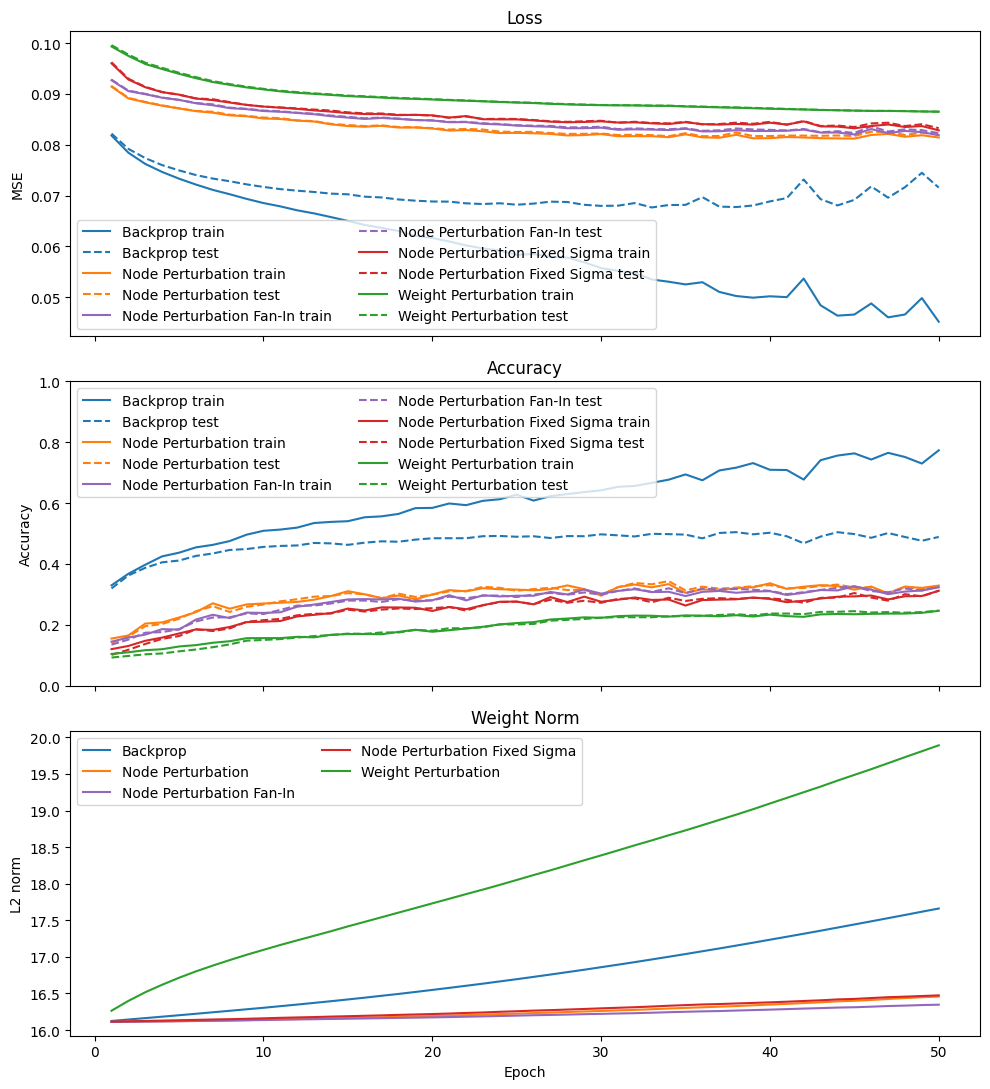

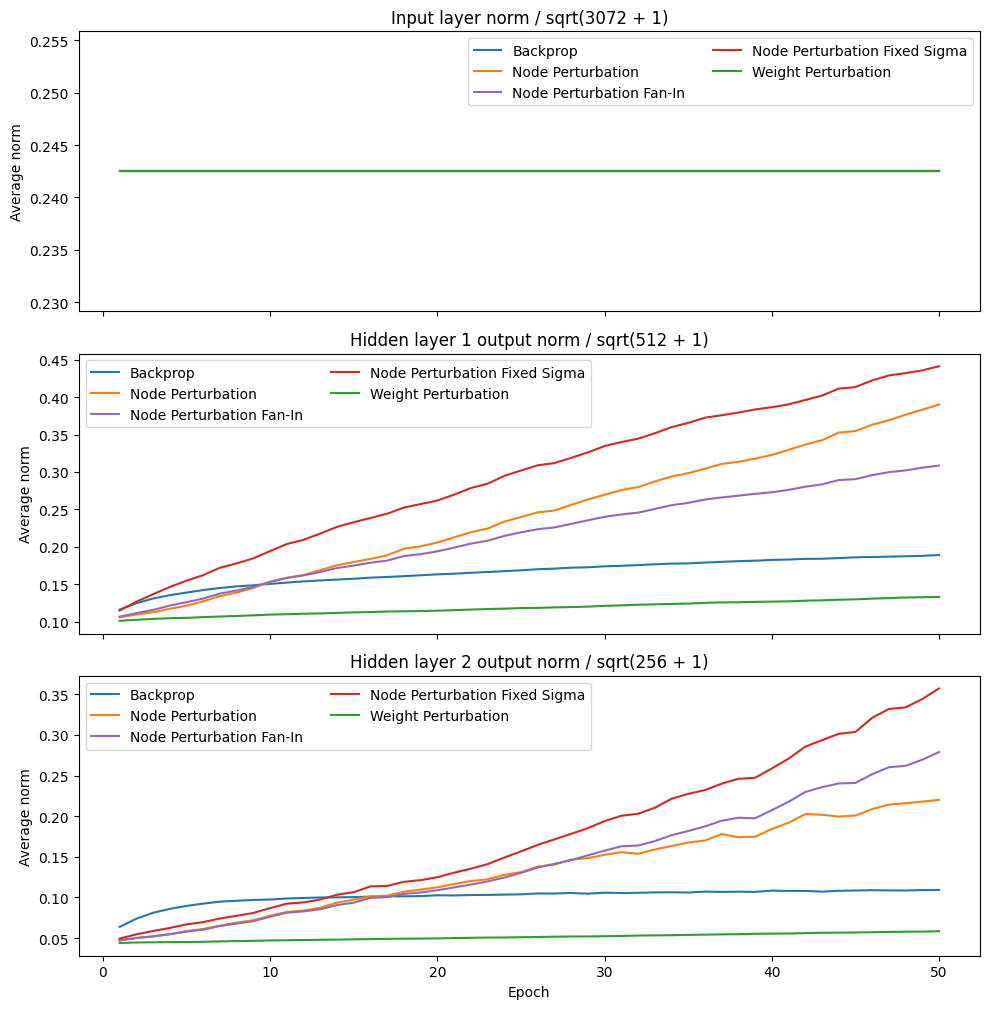

In [ ]:
# Run a deeper comparison on the best config per method.
# You can increase FINAL_EPOCHS if the sweep already identified a promising region.
FINAL_EPOCHS = 50
deep_results = run_best_config_comparison(
    best_df=best_configs_df,
    data=data,
    dimensions=DIMENSIONS,
    final_epochs=FINAL_EPOCHS,
    seed=0,
    device=device,
)

display(results_table(deep_results))
plot_training_histories(deep_results)
plot_layer_output_norm_histories(deep_results)


Running 5 config(s) | epochs=100, seed=0, dims=(3072, 512, 256, 10), device=cuda

### Final run | bp | lr=0.1
    epoch  1/100 | bp | lr=0.1 | train_loss=0.0846, train_acc=0.2953, test_loss=0.0848, test_acc=0.2838
    epoch  2/100 | bp | lr=0.1 | train_loss=0.0818, train_acc=0.3310, test_loss=0.0821, test_acc=0.3254
    epoch  3/100 | bp | lr=0.1 | train_loss=0.0797, train_acc=0.3598, test_loss=0.0804, test_acc=0.3530
    epoch  4/100 | bp | lr=0.1 | train_loss=0.0783, train_acc=0.3777, test_loss=0.0791, test_acc=0.3672
    epoch  5/100 | bp | lr=0.1 | train_loss=0.0771, train_acc=0.3882, test_loss=0.0781, test_acc=0.3766
    epoch  6/100 | bp | lr=0.1 | train_loss=0.0761, train_acc=0.3960, test_loss=0.0772, test_acc=0.3860
    epoch  7/100 | bp | lr=0.1 | train_loss=0.0753, train_acc=0.4060, test_loss=0.0765, test_acc=0.3960
    epoch  8/100 | bp | lr=0.1 | train_loss=0.0745, train_acc=0.4218, test_loss=0.0759, test_acc=0.4044
    epoch  9/100 | bp | lr=0.1 | train_loss=0.0738, train_

,method,final_train_loss,final_train_acc,final_test_loss,final_test_acc,best_test_loss,best_test_acc,diverged,duration_sec
0,bp,0.040217,0.82775,0.069489,0.5058,0.067326,0.5124,False,26.113683
1,np,0.080064,0.33925,0.080523,0.3422,0.080273,0.3470,False,42.535869
2,np_fan_in,NaN,0.10025,NaN,0.1028,0.082401,0.3258,True,34.076134
3,np_fixed,NaN,0.10025,NaN,0.1028,0.083343,0.3104,True,36.052951
4,wp,0.089400,0.24925,0.089136,0.2494,0.084872,0.2732,False,119.466215


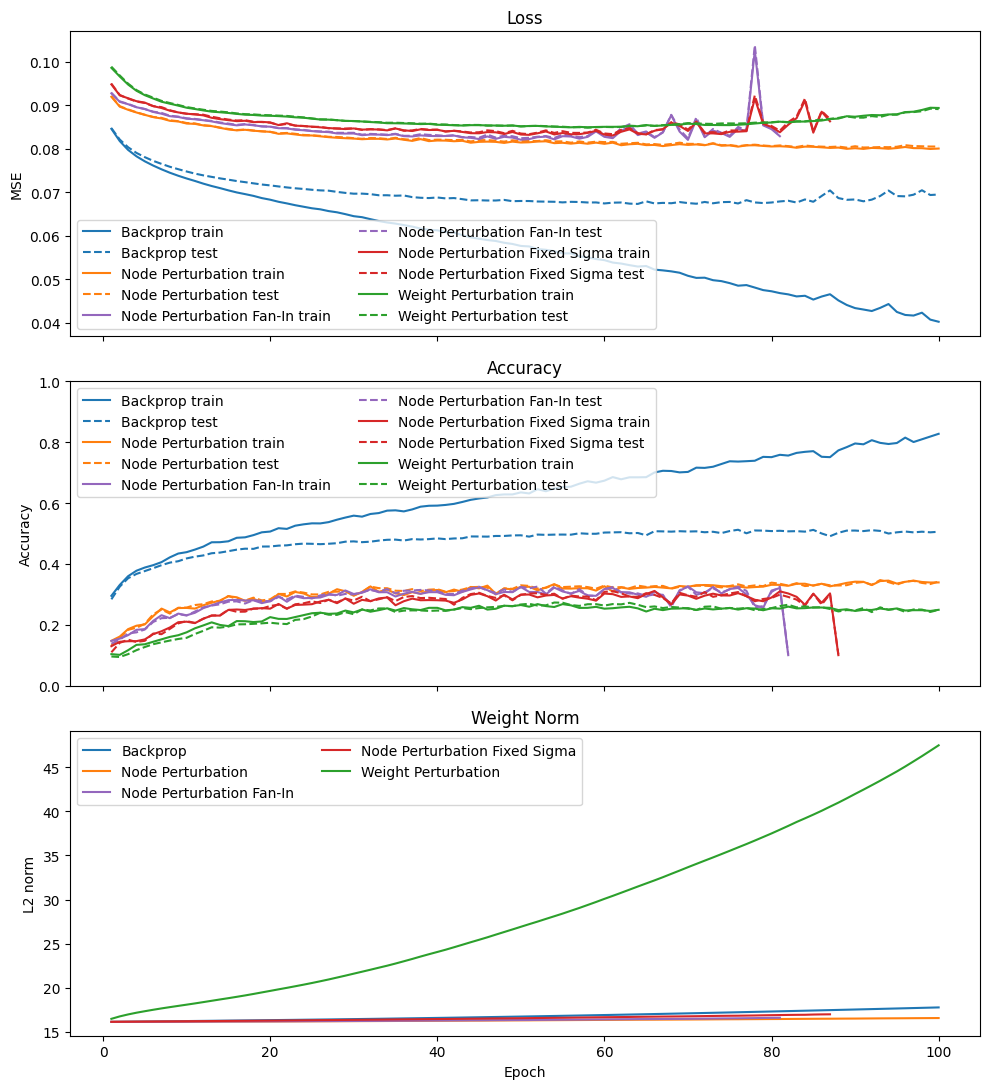

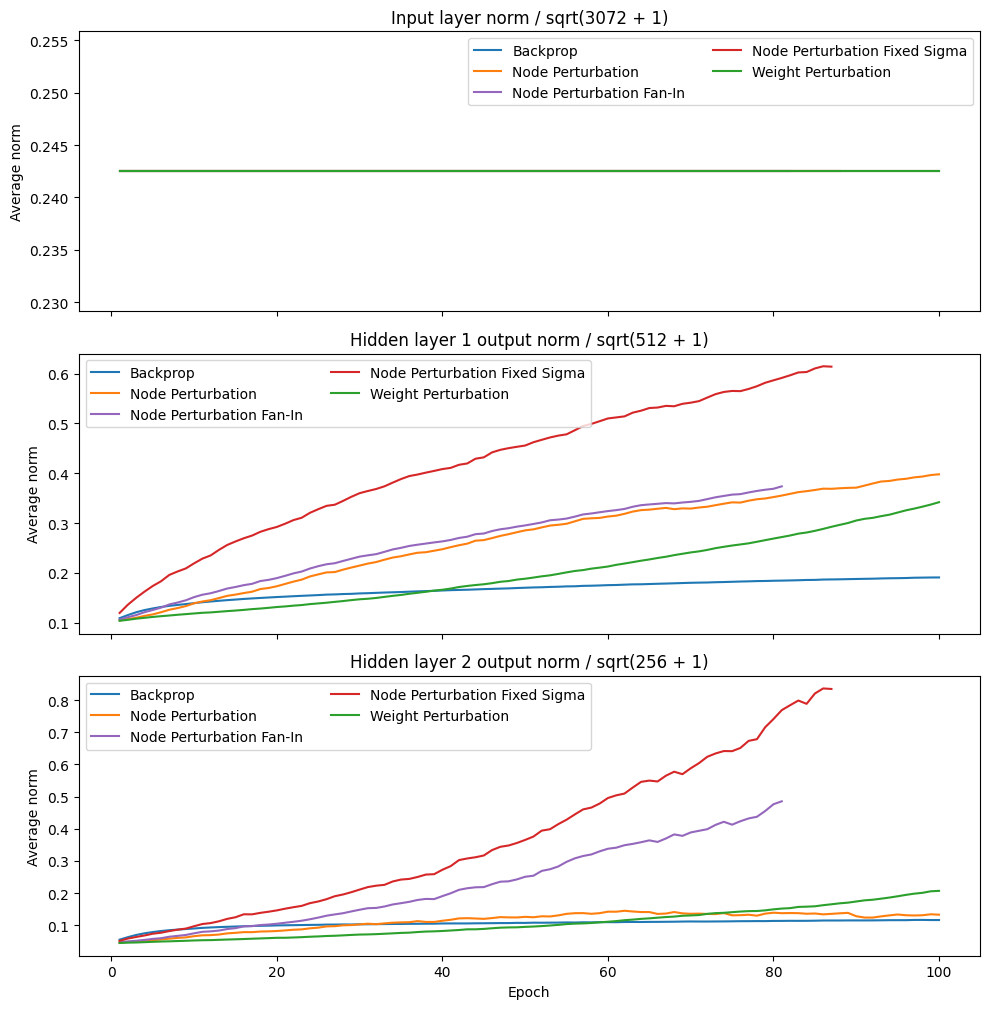

In [10]:
# Optional single-config runner.
# Edit RUN_CONFIGS and rerun this cell if you want to test one chosen setup.
METHODS = ["bp", "np", "np_fan_in", "np_fixed", "wp"]


RUN_EPOCHS = 100
RUN_SEED = 0
RUN_PRINT_EVERY_EPOCH = 1

RUN_CONFIGS = {
    "bp": {"lr": 0.1},
    "np": {"lr": (0.18/6)*0.4, "sigma": 0.0175},
    "np_fan_in": {"lr": (0.15/6)*0.4, "sigma": 0.0055},
    "np_fixed": {"lr": (0.09/6)*0.4, "sigma": 0.19},
    "wp": {"lr": (0.036/6)*0.4, "sigma": 0.0125},
}

single_results = {}

print(
    f"Running {len(RUN_CONFIGS)} config(s) | "
    f"epochs={RUN_EPOCHS}, seed={RUN_SEED}, dims={DIMENSIONS}, device={device}"
)

for method in METHODS:
    if method not in RUN_CONFIGS:
        continue
    config = RUN_CONFIGS[method]
    sigma_str = f", sigma={config['sigma']:.4g}" if "sigma" in config else ""
    print()
    print(f"### Final run | {method} | lr={config['lr']:.4g}{sigma_str}")
    single_results[method] = train_one_run(
        method=method,
        run_config=config,
        data=data,
        dimensions=DIMENSIONS,
        epochs=RUN_EPOCHS,
        seed=RUN_SEED,
        device=device,
        print_every_epoch=RUN_PRINT_EVERY_EPOCH,
    )

display(results_table(single_results))
plot_training_histories(single_results)
plot_layer_output_norm_histories(single_results)


# Frozen-Backprop Estimator Analysis

Train only backprop, freeze the weights after 1/3, 2/3, and 3/3 of training, then evaluate perturbation estimators on a full epoch of batches.
For each batch and method, sample 50 perturbations, compute the average sample cosine to the true gradient, the cosine of the mean estimator, and the sample variance around the mean estimator.


Running frozen estimator analysis | epochs=20, seed=0, bp_lr=0.1, checkpoints=[6, 13, 20], num_perturbations=10, batch_size=128
{'np': 0.0175, 'np_fan_in': 0.0055, 'np_fixed': 0.19, 'wp': 0.0125}
    bp checkpoint training epoch    1/20 | train_loss=0.0846, train_acc=0.2925, test_loss=0.0847, test_acc=0.2888
    bp checkpoint training epoch    2/20 | train_loss=0.0818, train_acc=0.3300, test_loss=0.0821, test_acc=0.3190
    bp checkpoint training epoch    4/20 | train_loss=0.0783, train_acc=0.3740, test_loss=0.0791, test_acc=0.3606
    bp checkpoint training epoch    6/20 | train_loss=0.0762, train_acc=0.3970, test_loss=0.0772, test_acc=0.3848
    bp checkpoint training epoch    8/20 | train_loss=0.0746, train_acc=0.4240, test_loss=0.0760, test_acc=0.4066
    bp checkpoint training epoch   10/20 | train_loss=0.0732, train_acc=0.4387, test_loss=0.0748, test_acc=0.4192
    bp checkpoint training epoch   12/20 | train_loss=0.0720, train_acc=0.4595, test_loss=0.0739, test_acc=0.4294
    bp

/tmp/ipykernel_947/3594577182.py:262: UserWarning: Converting a tensor with requires_grad=True to a scalar may lead to unexpected behavior.
Consider using tensor.detach() first. (Triggered internally at /pytorch/torch/csrc/autograd/generated/python_variable_methods.cpp:836.)
  return float(torch.dot(a, b) / (a_norm * b_norm + eps))


,checkpoint_epoch,checkpoint_fraction,method,sigma,component,component_label,layer_index,avg_sample_cosine,mean_estimate_cosine,sample_variance,batch_variance
0,6,0.30,np,0.0175,all,All layers,-1,0.013526,0.042783,0.000006,6.063875e-07
1,6,0.30,np_fan_in,0.0055,all,All layers,-1,0.011756,0.037066,0.000007,7.111999e-07
2,6,0.30,np_fixed,0.1900,all,All layers,-1,0.006235,0.019708,0.000029,2.905991e-06
3,6,0.30,wp,0.0125,all,All layers,-1,0.000242,0.000771,0.020449,2.044805e-03
4,13,0.65,np,0.0175,all,All layers,-1,0.015150,0.048029,0.000009,9.550900e-07
5,13,0.65,np_fan_in,0.0055,all,All layers,-1,0.015967,0.050084,0.000010,1.037266e-06
6,13,0.65,np_fixed,0.1900,all,All layers,-1,0.007870,0.025126,0.000033,3.277869e-06
7,13,0.65,wp,0.0125,all,All layers,-1,0.000315,0.001000,0.030696,3.069493e-03
8,20,1.00,np,0.0175,all,All layers,-1,0.010668,0.033713,0.000011,1.160261e-06
9,20,1.00,np_fan_in,0.0055,all,All layers,-1,0.008696,0.027353,0.000012,1.218295e-06


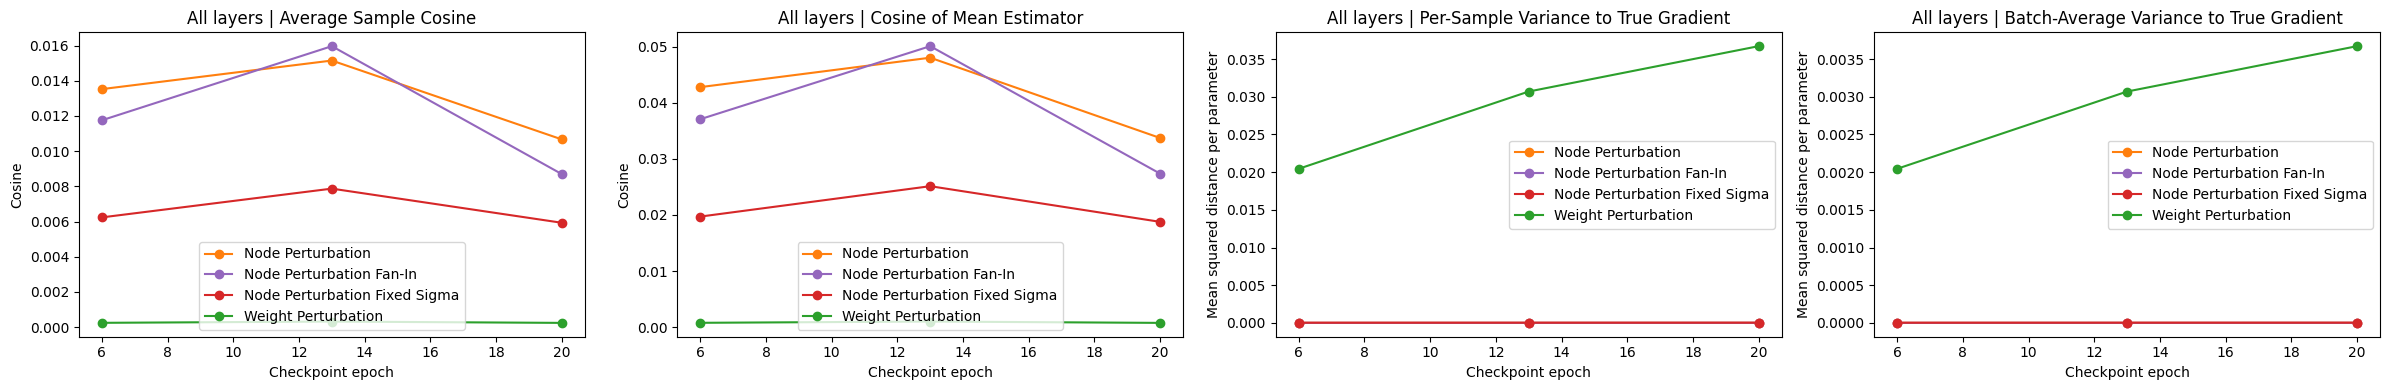

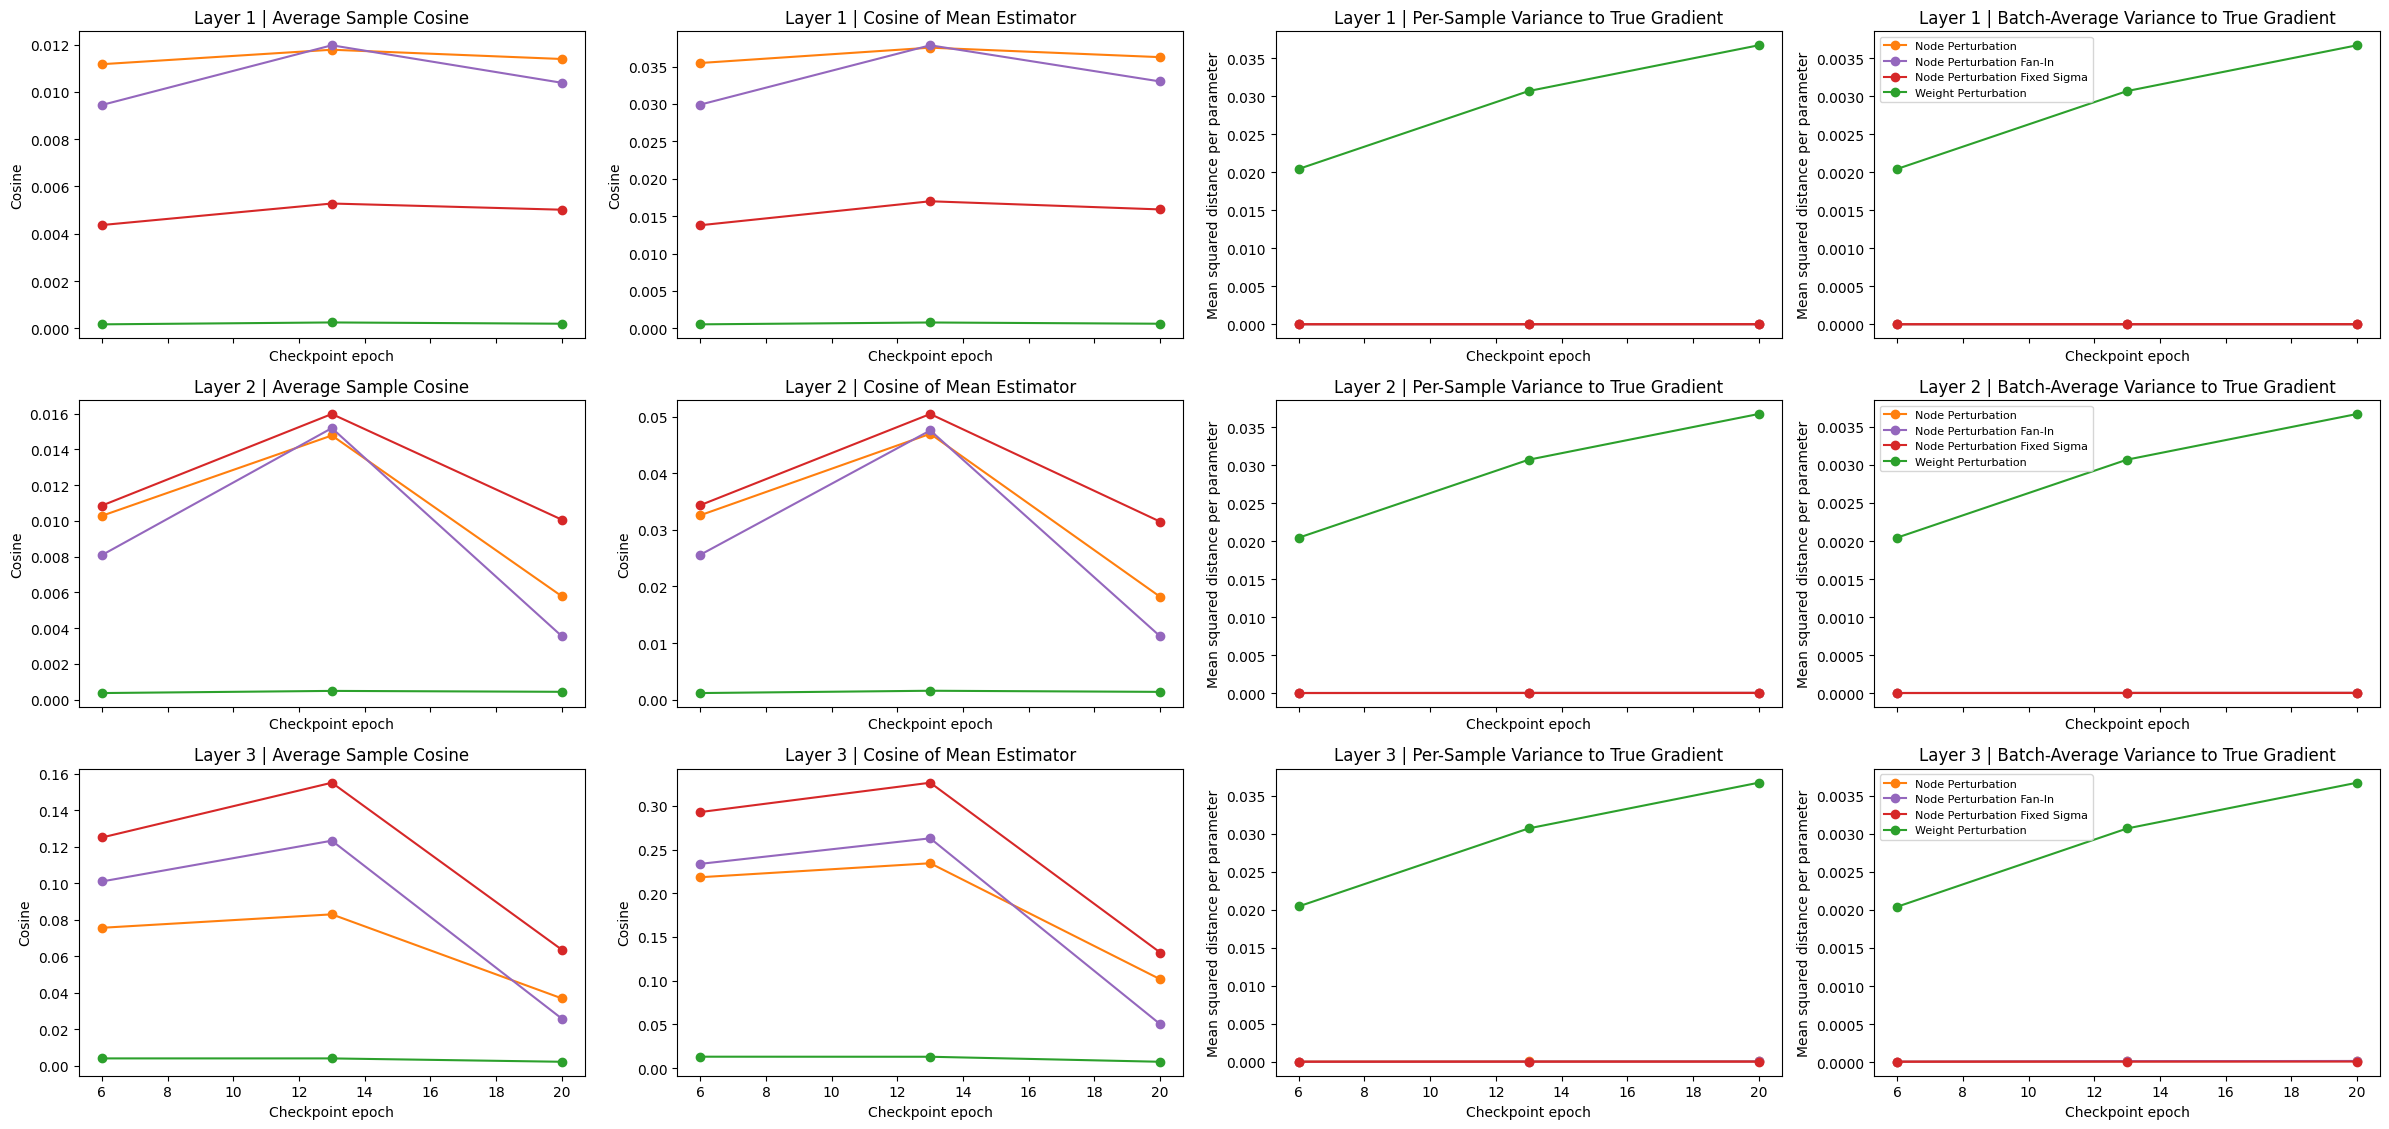

In [9]:
# Frozen-backprop estimator analysis.
# Uses the same sigma values as the current hand-picked final run, but no learning rate.

ANALYSIS_EPOCHS = FINAL_EPOCHS
ANALYSIS_SEED = 0
ANALYSIS_BP_LR = 0.1
ANALYSIS_NUM_PERTURBATIONS = 10
ANALYSIS_BATCH_SIZE = BATCH_SIZE
ANALYSIS_CHECKPOINT_EPOCHS = sorted({max(1, ANALYSIS_EPOCHS // 3), max(1, (2 * ANALYSIS_EPOCHS) // 3), ANALYSIS_EPOCHS})
ANALYSIS_METHOD_SIGMAS = {
    "np": 0.0175,
    "np_fan_in": 0.0055,
    "np_fixed": 0.19,
    "wp": 0.0125,
}

print(
    f"Running frozen estimator analysis | epochs={ANALYSIS_EPOCHS}, seed={ANALYSIS_SEED}, "
    f"bp_lr={ANALYSIS_BP_LR}, checkpoints={ANALYSIS_CHECKPOINT_EPOCHS}, "
    f"num_perturbations={ANALYSIS_NUM_PERTURBATIONS}, batch_size={ANALYSIS_BATCH_SIZE}"
)
print(ANALYSIS_METHOD_SIGMAS)

checkpoint_states = train_backprop_checkpoint_states(
    data=data,
    dimensions=DIMENSIONS,
    epochs=ANALYSIS_EPOCHS,
    seed=ANALYSIS_SEED,
    device=device,
    lr=ANALYSIS_BP_LR,
    checkpoint_epochs=ANALYSIS_CHECKPOINT_EPOCHS,
    print_every_epoch=max(1, ANALYSIS_EPOCHS // 10),
)

frozen_stats_df = analyze_frozen_backprop_estimators(
    checkpoint_states=checkpoint_states,
    data=data,
    dimensions=DIMENSIONS,
    device=device,
    method_sigmas=ANALYSIS_METHOD_SIGMAS,
    num_perturbations=ANALYSIS_NUM_PERTURBATIONS,
    batch_size=ANALYSIS_BATCH_SIZE,
)

display(frozen_stats_df.sort_values(["layer_index", "checkpoint_epoch", "method"]).reset_index(drop=True))
plot_frozen_estimator_statistics(frozen_stats_df)


# Frozen-Backprop Sigma Search

Run the same frozen-backprop repeated-perturbation analysis as above, but sweep only over `sigma` for each perturbation method.
The plots are grouped per method, with one row per checkpoint epoch and separate bar panels for average sample cosine, cosine of the mean estimator, and sample variance.


Running frozen sigma search | epochs=20, seed=0, bp_lr=0.1, checkpoints=[6, 13, 20], num_perturbations=10, batch_size=128
{'np': [0.0175, 0.01875, 0.02], 'np_fan_in': [0.0045, 0.0055, 0.0065], 'np_fixed': [0.165, 0.19, 0.215], 'wp': [0.015, 0.0175, 0.02]}
    bp checkpoint training epoch    1/20 | train_loss=0.0846, train_acc=0.2925, test_loss=0.0847, test_acc=0.2886
    bp checkpoint training epoch    2/20 | train_loss=0.0818, train_acc=0.3297, test_loss=0.0821, test_acc=0.3192
    bp checkpoint training epoch    4/20 | train_loss=0.0783, train_acc=0.3745, test_loss=0.0791, test_acc=0.3612
    bp checkpoint training epoch    6/20 | train_loss=0.0762, train_acc=0.3967, test_loss=0.0772, test_acc=0.3848
    bp checkpoint training epoch    8/20 | train_loss=0.0746, train_acc=0.4245, test_loss=0.0760, test_acc=0.4072
    bp checkpoint training epoch   10/20 | train_loss=0.0732, train_acc=0.4390, test_loss=0.0748, test_acc=0.4198
    bp checkpoint training epoch   12/20 | train_loss=0.0720

,checkpoint_epoch,checkpoint_fraction,method,sigma,avg_sample_cosine,mean_estimate_cosine,sample_variance,batch_variance
0,6,0.30,np,0.01750,0.013194,0.041788,0.000006,6.028016e-07
1,6,0.30,np,0.01875,0.013294,0.042053,0.000006,5.740380e-07
2,6,0.30,np,0.02000,0.012901,0.040963,0.000006,5.644675e-07
3,13,0.65,np,0.01750,0.015797,0.049981,0.000009,9.536539e-07
4,13,0.65,np,0.01875,0.015249,0.048320,0.000009,9.220225e-07
5,13,0.65,np,0.02000,0.015963,0.050248,0.000009,9.048351e-07
6,20,1.00,np,0.01750,0.010523,0.033254,0.000011,1.155963e-06
7,20,1.00,np,0.01875,0.009872,0.031213,0.000011,1.128209e-06
8,20,1.00,np,0.02000,0.010131,0.031948,0.000011,1.130038e-06
9,6,0.30,np_fan_in,0.00450,0.012084,0.038199,0.000008,7.635565e-07


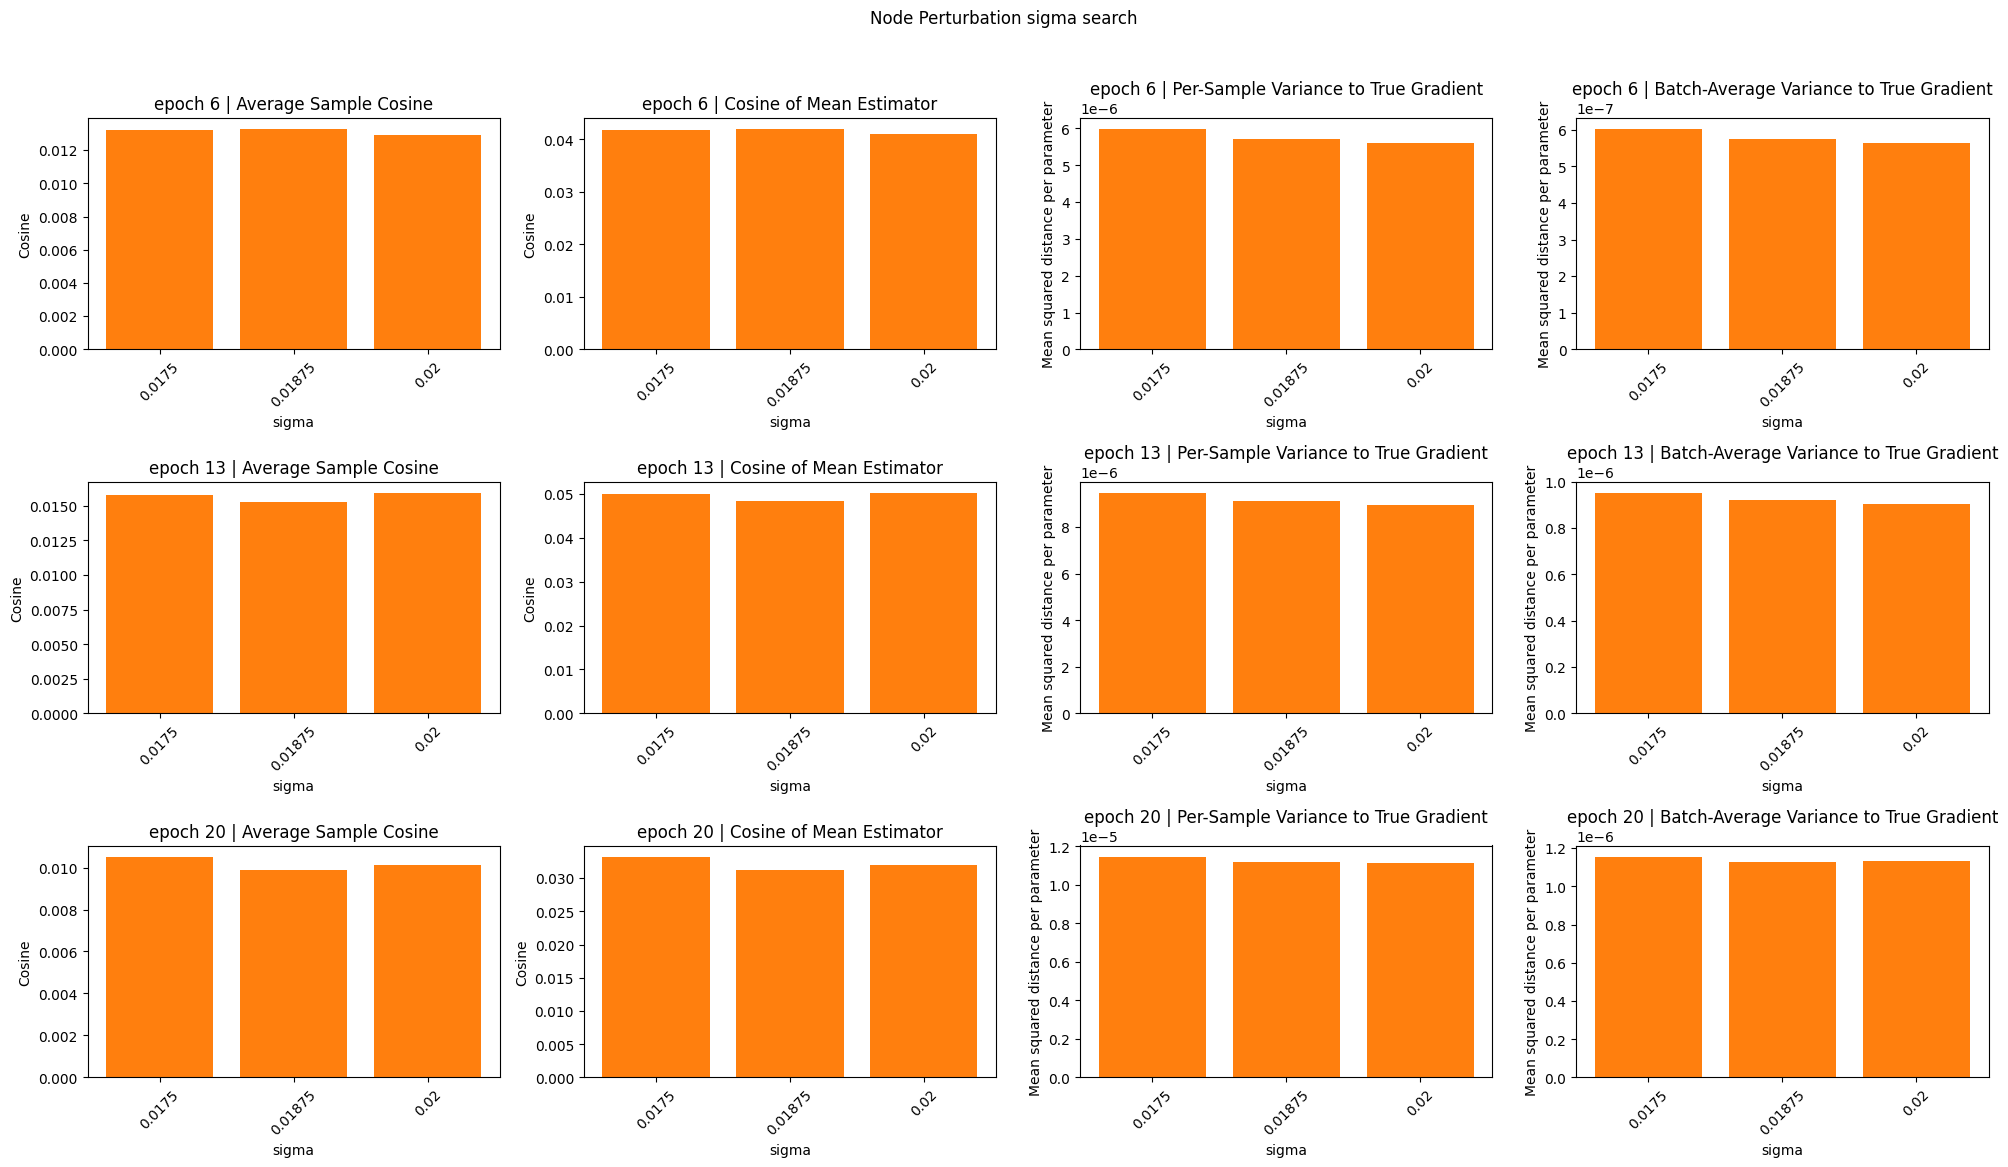

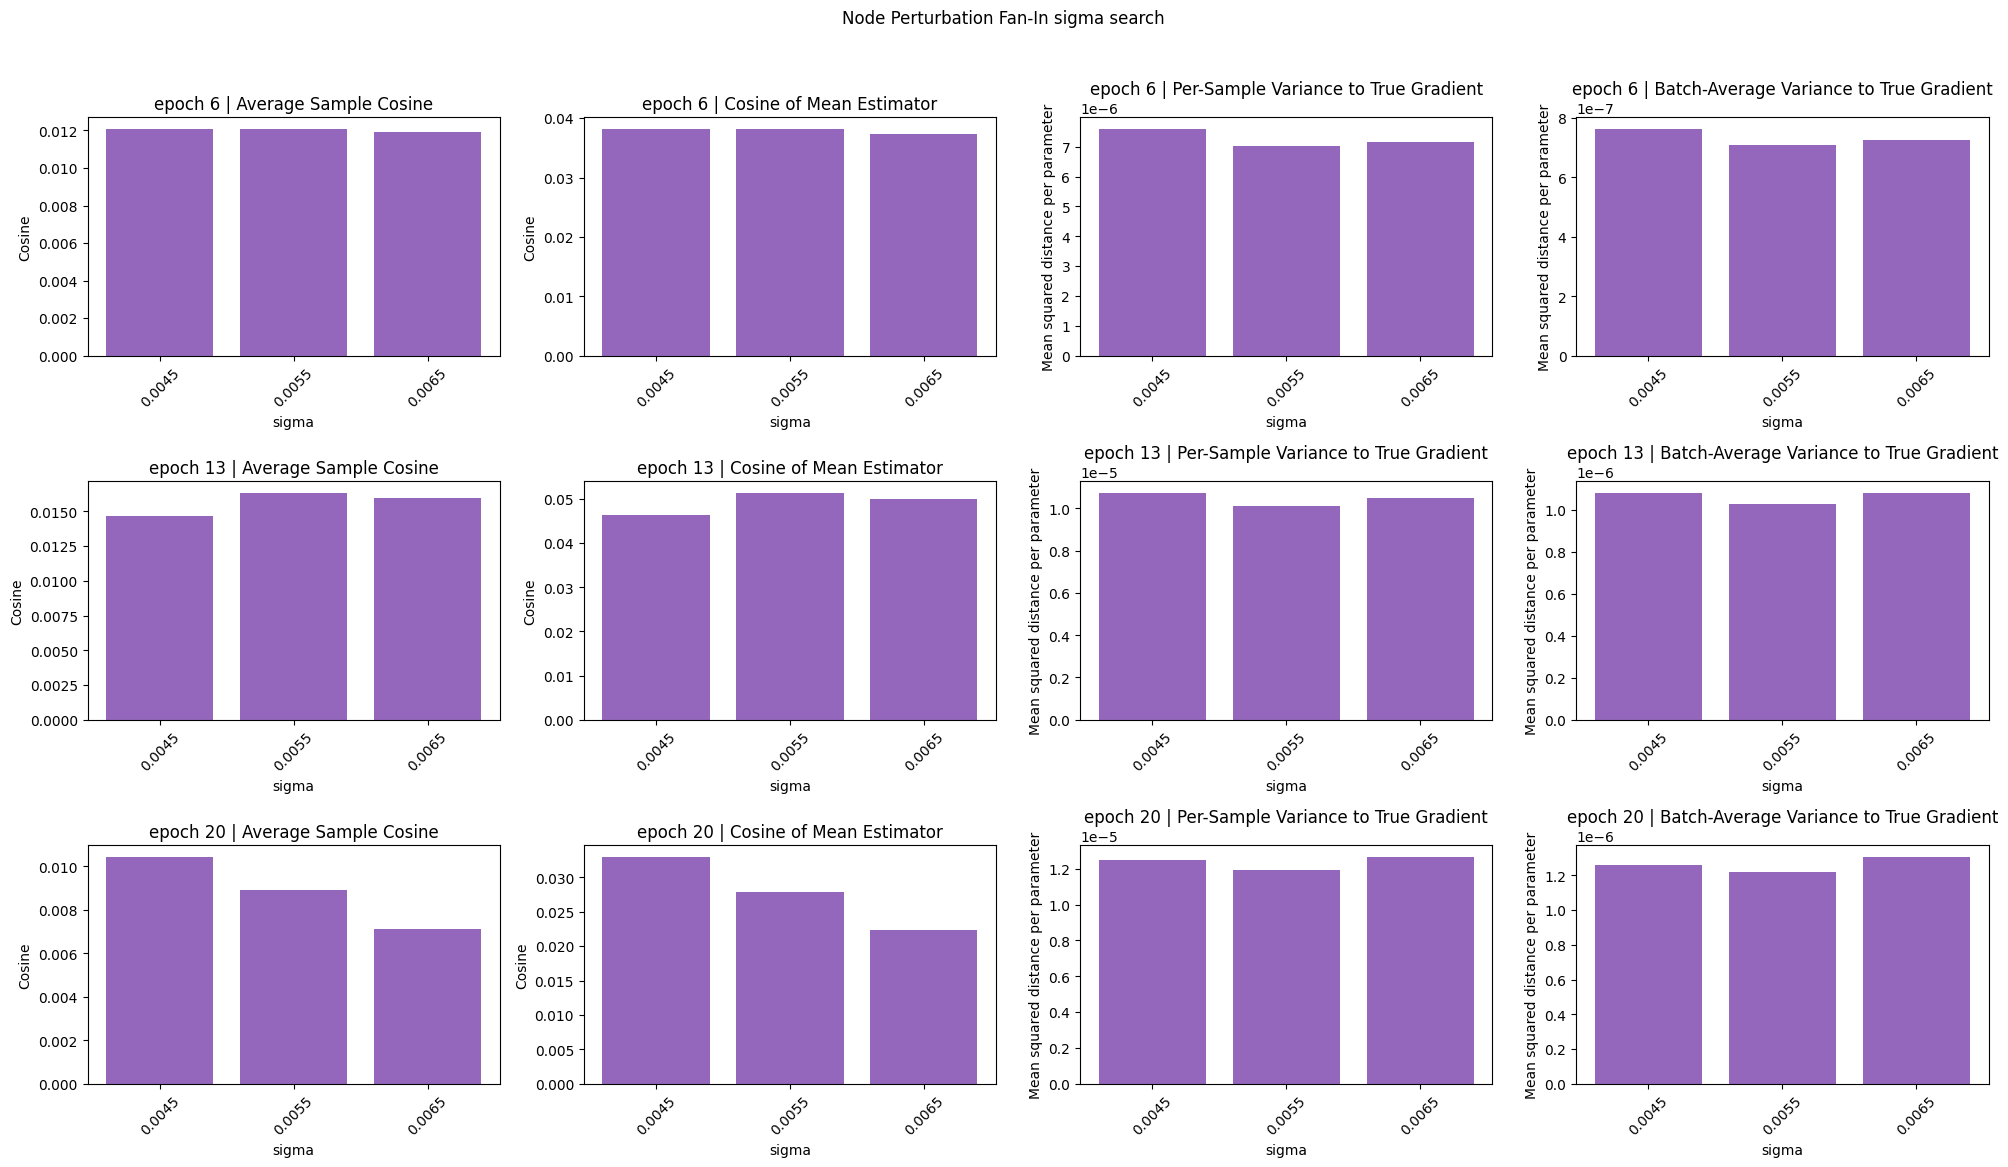

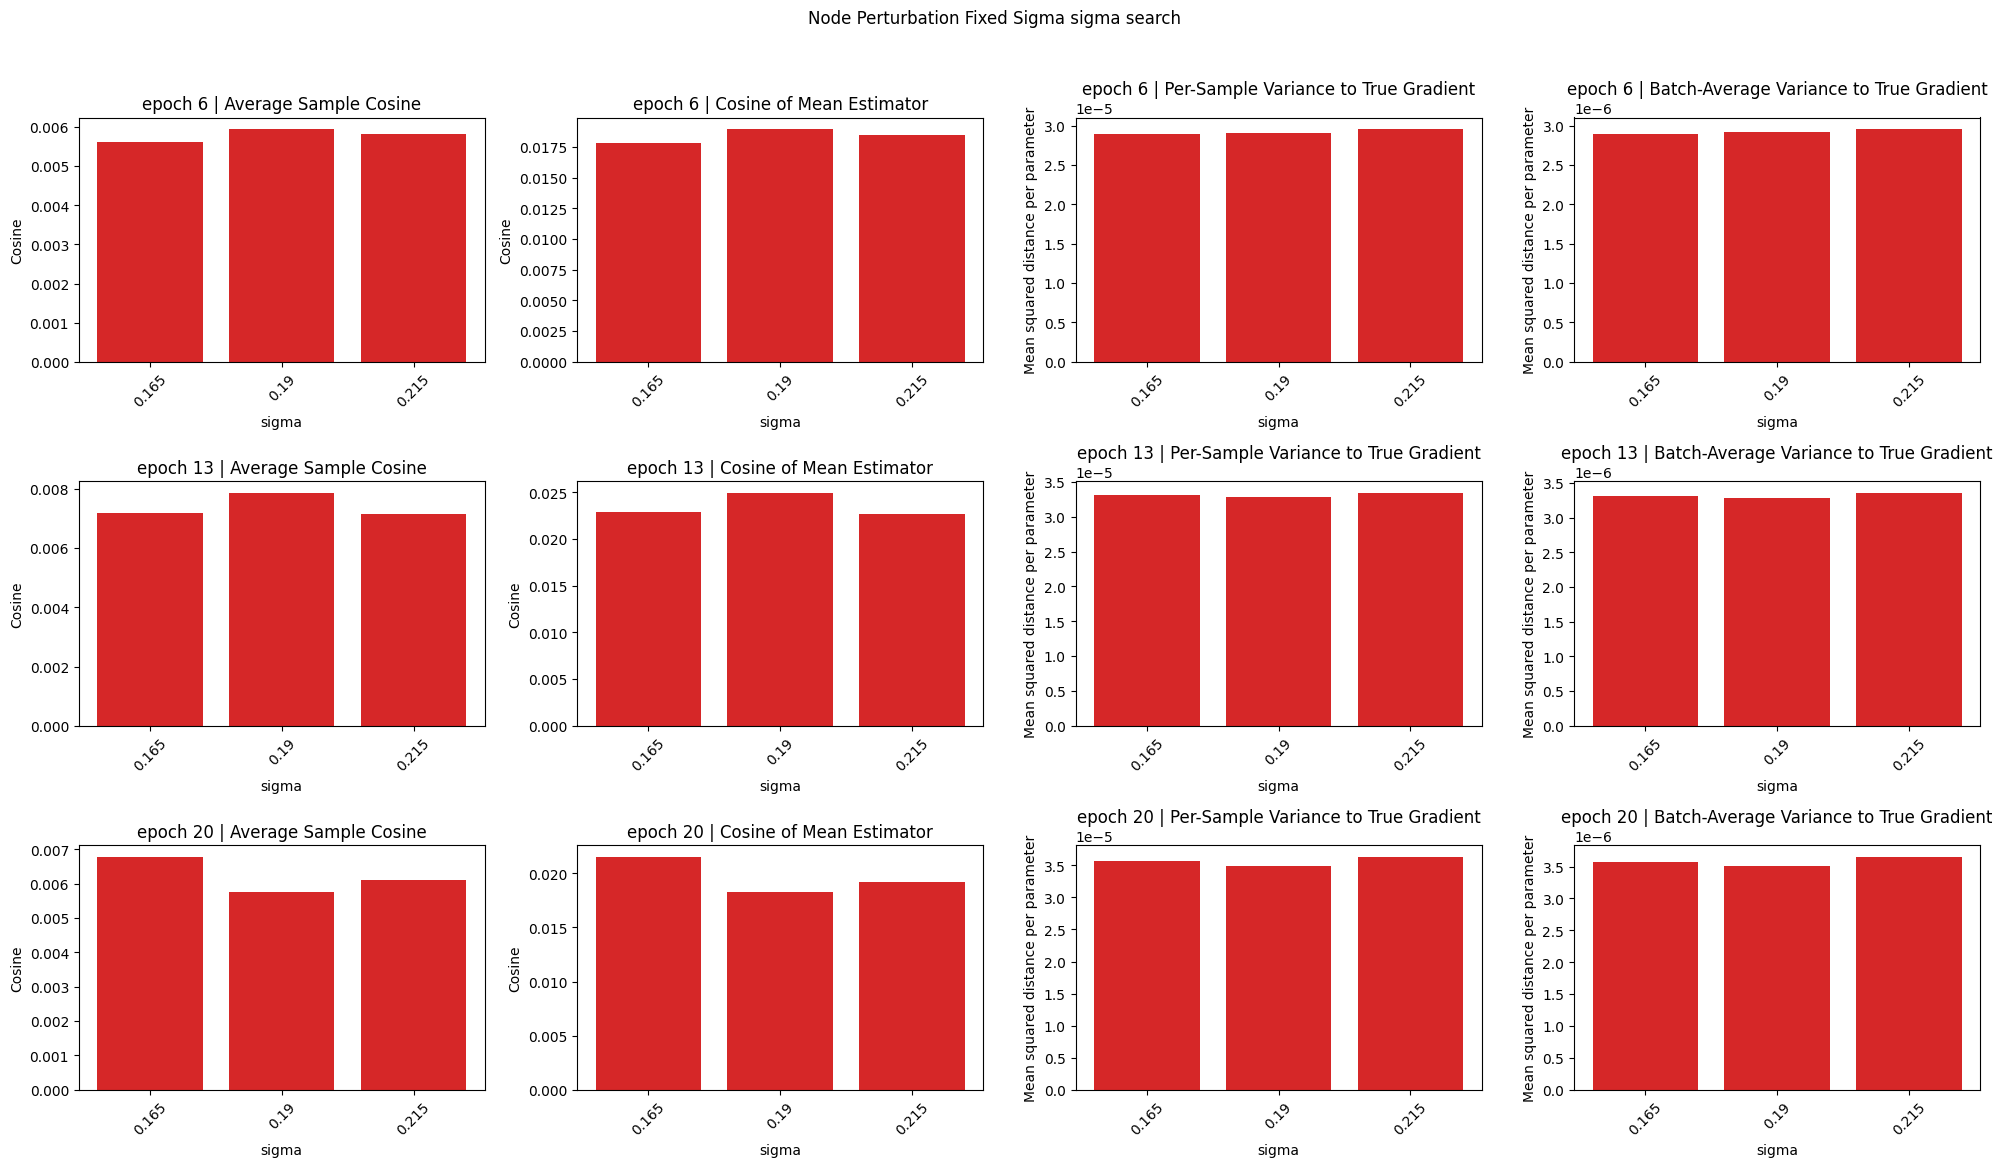

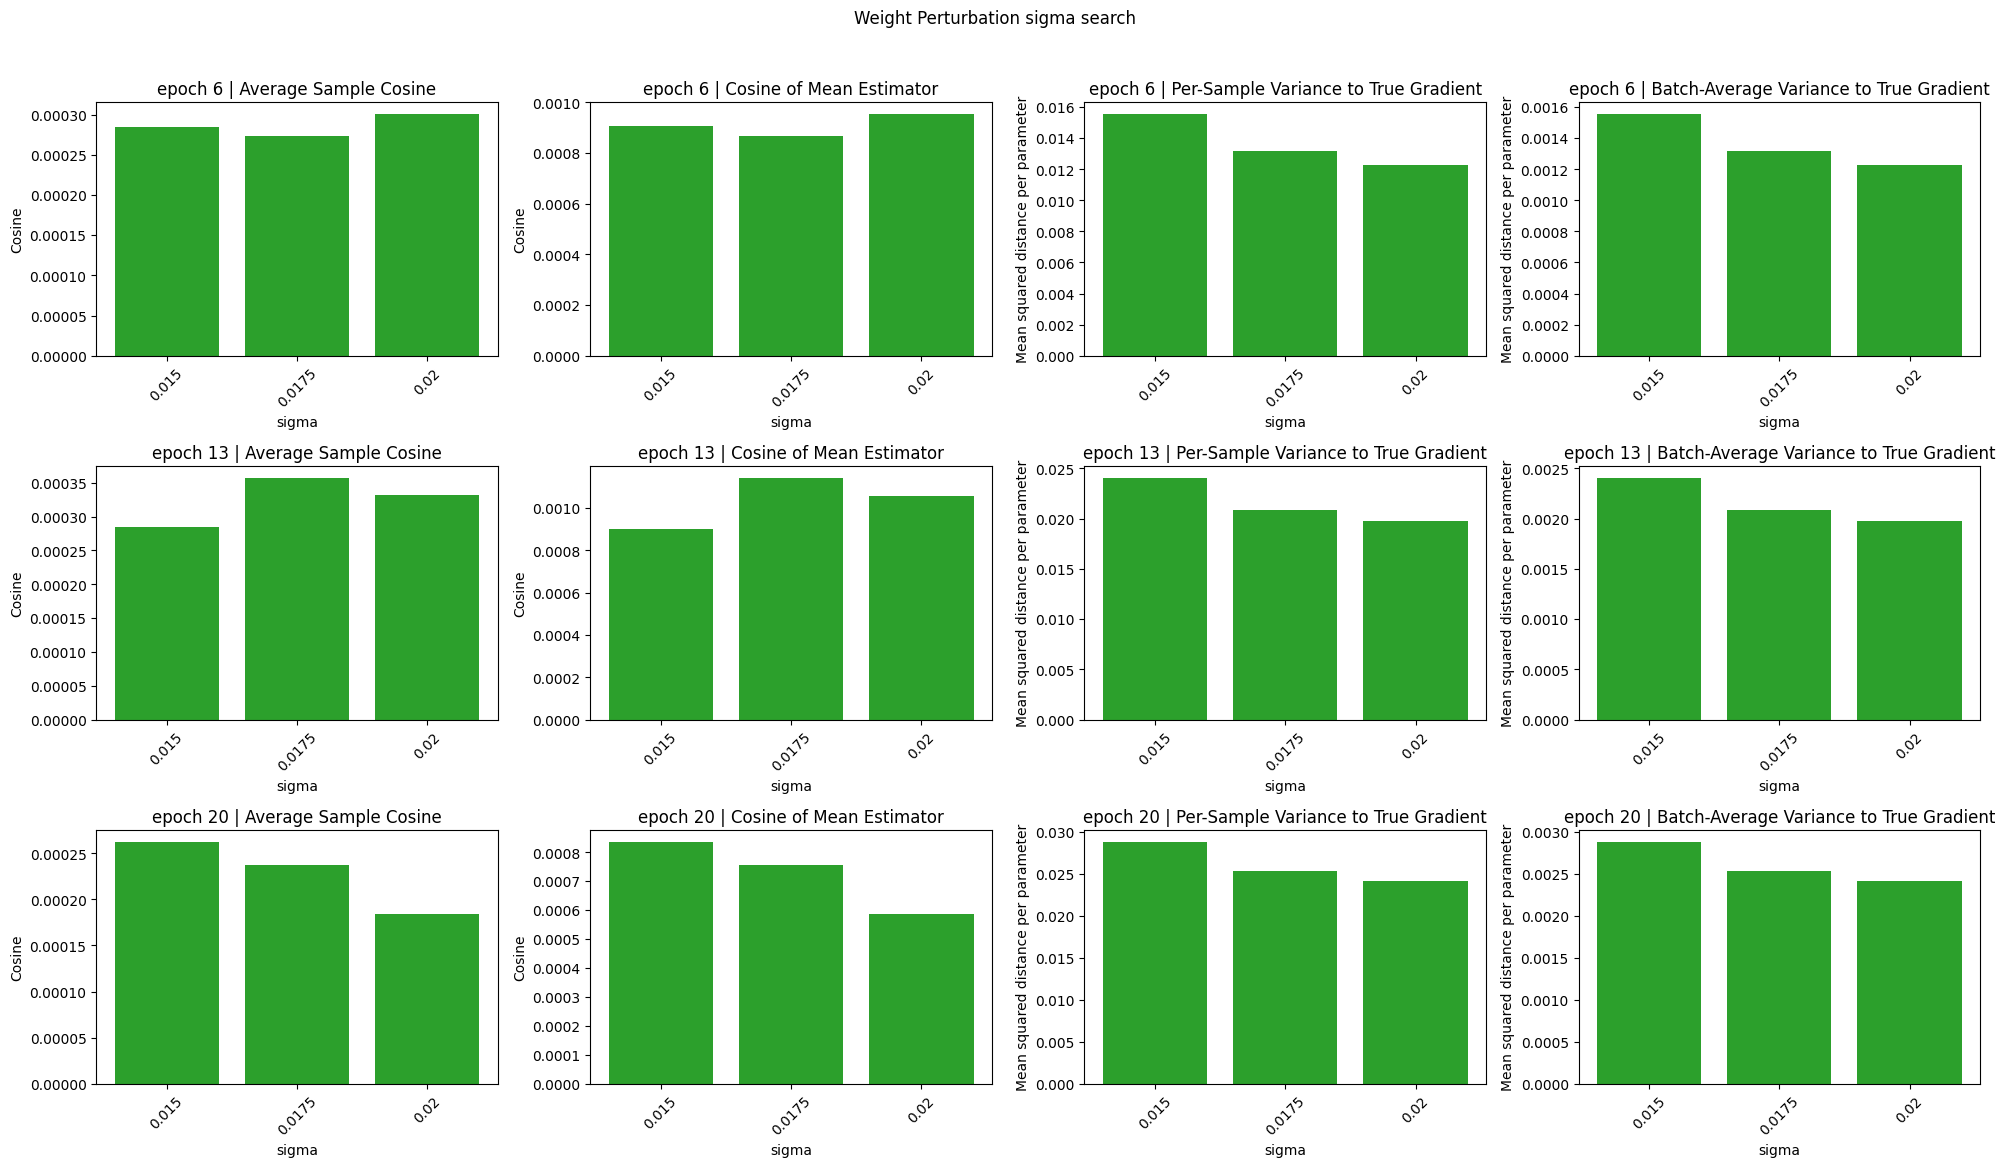

In [ ]:
# Frozen-backprop sigma search.
# Reuses the repeated-perturbation estimator procedure, but sweeps only over sigma.

SIGMA_SEARCH_EPOCHS = FINAL_EPOCHS
SIGMA_SEARCH_SEED = 0
SIGMA_SEARCH_BP_LR = 0.1
SIGMA_SEARCH_NUM_PERTURBATIONS = 10
SIGMA_SEARCH_BATCH_SIZE = BATCH_SIZE
SIGMA_SEARCH_CHECKPOINT_EPOCHS = sorted({max(1, SIGMA_SEARCH_EPOCHS // 3), max(1, (2 * SIGMA_SEARCH_EPOCHS) // 3), SIGMA_SEARCH_EPOCHS})
SIGMA_SEARCH_METHOD_SIGMA_GRID = {
    "np": [
        0.0175,
        0.01875,
        0.02,
    ],
    "np_fan_in": [
        0.0045,
        0.005,
        0.0055,
    ],
    "np_fixed": [
        0.165,
        0.19,
        0.215,
    ],
    "wp": [
        0.015,
        0.0175,
        0.02,
    ]
}

print(
    f"Running frozen sigma search | epochs={SIGMA_SEARCH_EPOCHS}, seed={SIGMA_SEARCH_SEED}, "
    f"bp_lr={SIGMA_SEARCH_BP_LR}, checkpoints={SIGMA_SEARCH_CHECKPOINT_EPOCHS}, "
    f"num_perturbations={SIGMA_SEARCH_NUM_PERTURBATIONS}, batch_size={SIGMA_SEARCH_BATCH_SIZE}"
)
print(SIGMA_SEARCH_METHOD_SIGMA_GRID)

if "checkpoint_states" in globals() and sorted(checkpoint_states.keys()) == SIGMA_SEARCH_CHECKPOINT_EPOCHS:
    sigma_search_checkpoint_states = checkpoint_states
else:
    sigma_search_checkpoint_states = train_backprop_checkpoint_states(
        data=data,
        dimensions=DIMENSIONS,
        epochs=SIGMA_SEARCH_EPOCHS,
        seed=SIGMA_SEARCH_SEED,
        device=device,
        lr=SIGMA_SEARCH_BP_LR,
        checkpoint_epochs=SIGMA_SEARCH_CHECKPOINT_EPOCHS,
        print_every_epoch=max(1, SIGMA_SEARCH_EPOCHS // 10),
    )

sigma_search_df = analyze_frozen_backprop_sigma_grid(
    checkpoint_states=sigma_search_checkpoint_states,
    data=data,
    dimensions=DIMENSIONS,
    device=device,
    method_sigma_grid=SIGMA_SEARCH_METHOD_SIGMA_GRID,
    num_perturbations=SIGMA_SEARCH_NUM_PERTURBATIONS,
    batch_size=SIGMA_SEARCH_BATCH_SIZE,
)

display(sigma_search_df.sort_values(["method", "checkpoint_epoch", "sigma"]).reset_index(drop=True))
plot_frozen_sigma_search_results(sigma_search_df)
